# Measuring emission line fluxes

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/Users/javieratoro/Desktop/proyecto 2024-2/nava_data/analogs'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/Users/javieratoro/Desktop/proyecto 2024-2/nava_data/analogs/specs/final_spec'
os.chdir(PATH)
os.getcwd()

DIR = '/Users/javieratoro/Desktop/proyecto 2024-2'

In [4]:
# read the data
import pandas as pd
galname = 'J0136'
j0136 = pd.read_csv(galname + '.csv')

wave = j0136['wave'].to_numpy()
flux = j0136['flux'].to_numpy() * 1e17
err = j0136['noise'].to_numpy() * 1e17
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise
        
# Main lines

# [NII]6548 + Ha + [NII]6584
select = (wave > 6925) * (wave < 6990)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5290) * (wave < 5325)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 7725) * (wave < 7800)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 7090) * (wave < 7160)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6080) * (wave < 6120)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5135) * (wave < 5170)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# Hg
select = (wave > 4585) * (wave < 4615)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4330) * (wave < 4365)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4300) * (wave < 4330)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 3940) * (wave < 3960)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# [SIII]9532
select = (wave > 10050) * (wave < 10150)
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9560) * (wave < 9660)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [Ar III]7135
select = (wave > 7520) * (wave < 7600)
ariii_7135 = SpecPiece('ariii_7135', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6650) * (wave < 6720)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5230) * (wave < 5280)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# HeII4686
select = (wave > 4920) * (wave < 5000)
heii_4686 = SpecPiece('heii4686', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4610) * (wave < 4640)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4080) * (wave < 4120)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

Text(0.5, 0, 'Obs wavelength ($\\AA$)')

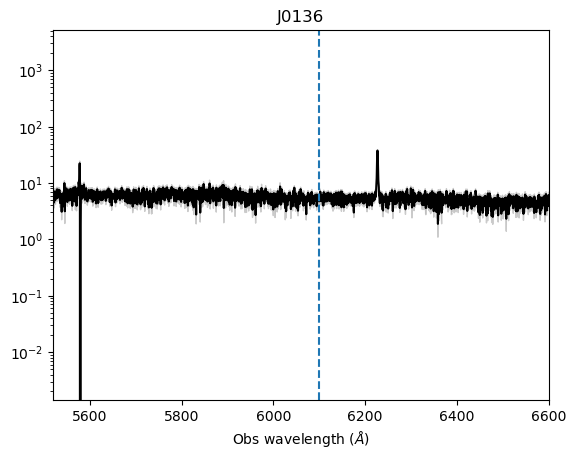

In [5]:
plt.plot(wave, flux, color='black')
plt.xlim(5520, 6600)
#plt.ylim(1e-17, 1e-15)
plt.axvline((1 + z_BN[igal])*wave_cat['[NII]5755'], ls='--')
plt.fill_between(wave, flux-err, flux+err, alpha=0.4, color='gray')
plt.yscale('log')
plt.title('J0136')
plt.xlabel('Obs wavelength ($\AA$)')
#plt.savefig('/home/benjamin/Documents/analogs/HeIIJ0136.pdf', bbox_inches='tight')

# Two component model fit for [OIII] 4959

# [OIII]4959

In [6]:
m = arc_slope19b
n = arc_intercept19b

sigma_arc_4959 = (m * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n

In [7]:
m_wer = ufloat(1.6064e-04, 7.3217e-06)
n_wer = ufloat(-0.04641747, 0.04768681)

sigma_arc_4959_wer = (m_wer * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n_wer

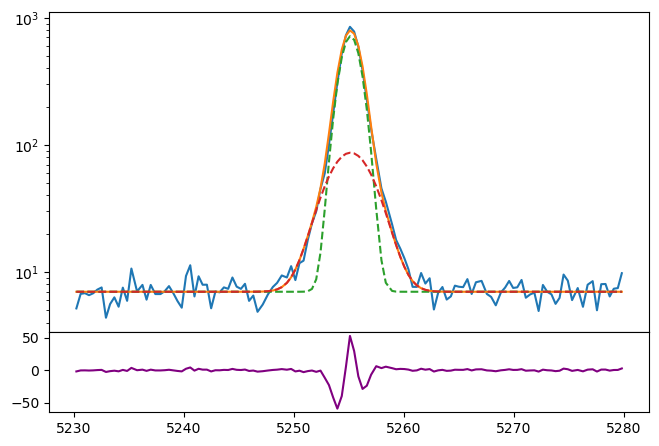

In [8]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 7

oiiib_nar = gaussian(oiii_4959.wavelength, 1600, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.9)
oiiib_brd = gaussian(oiii_4959.wavelength, 400, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=2.0)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [9]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=0.9, min=0.)
params_oiii_4959.add('sigma_brd', value=2.0, min=0.)
params_oiii_4959.add('Oiiib_nar', value=1600, min=0.)
params_oiii_4959.add('Oiiib_brd', value=400, min=0.)
params_oiii_4959.add('bkg', value=7, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [10]:
np.random.seed(136)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:08<00:00, 295.70it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 79.64753847  66.53236001 198.11914636 210.38783764 218.44924315
 219.8396372   55.72119657]


In [11]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05974383,7.1561e-07,(0.00%),0.05974,-inf,inf,True
z_brd,0.05977017,3.3783e-06,(0.01%),0.05974,-inf,inf,True
sigma_nar,0.78150285,0.00585478,(0.75%),0.9,0.00000000,inf,True
sigma_brd,1.80166124,0.03021177,(1.68%),2.0,0.00000000,inf,True
Oiiib_nar,1377.30429,18.8681393,(1.37%),1600,0.00000000,inf,True
Oiiib_brd,563.015125,17.9243194,(3.18%),400,0.00000000,inf,True
bkg,7.21444594,0.09028210,(1.25%),7,0.00000000,inf,True


In [12]:
np.random.seed(136)
out2_oiii_4959 = minimize(residual_oiii_4959, out_oiii_4959.params, args=(1, 1, 1), method='leastsq')

In [13]:
out2_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05974383,1.0581e-06,(0.00%),0.0597438274429159,-inf,inf,True
z_brd,0.05977015,4.9672e-06,(0.01%),0.059770168855444256,-inf,inf,True
sigma_nar,0.78159095,0.00778588,(1.00%),0.7815028507076323,0.00000000,inf,True
sigma_brd,1.80287203,0.04115365,(2.28%),1.8016612386835826,0.00000000,inf,True
Oiiib_nar,1377.88450,25.3394191,(1.84%),1377.3042902248376,0.00000000,inf,True
Oiiib_brd,562.468112,24.0006192,(4.27%),563.0151247295435,0.00000000,inf,True
bkg,7.21329910,0.13405962,(1.86%),7.214445936707293,0.00000000,inf,True


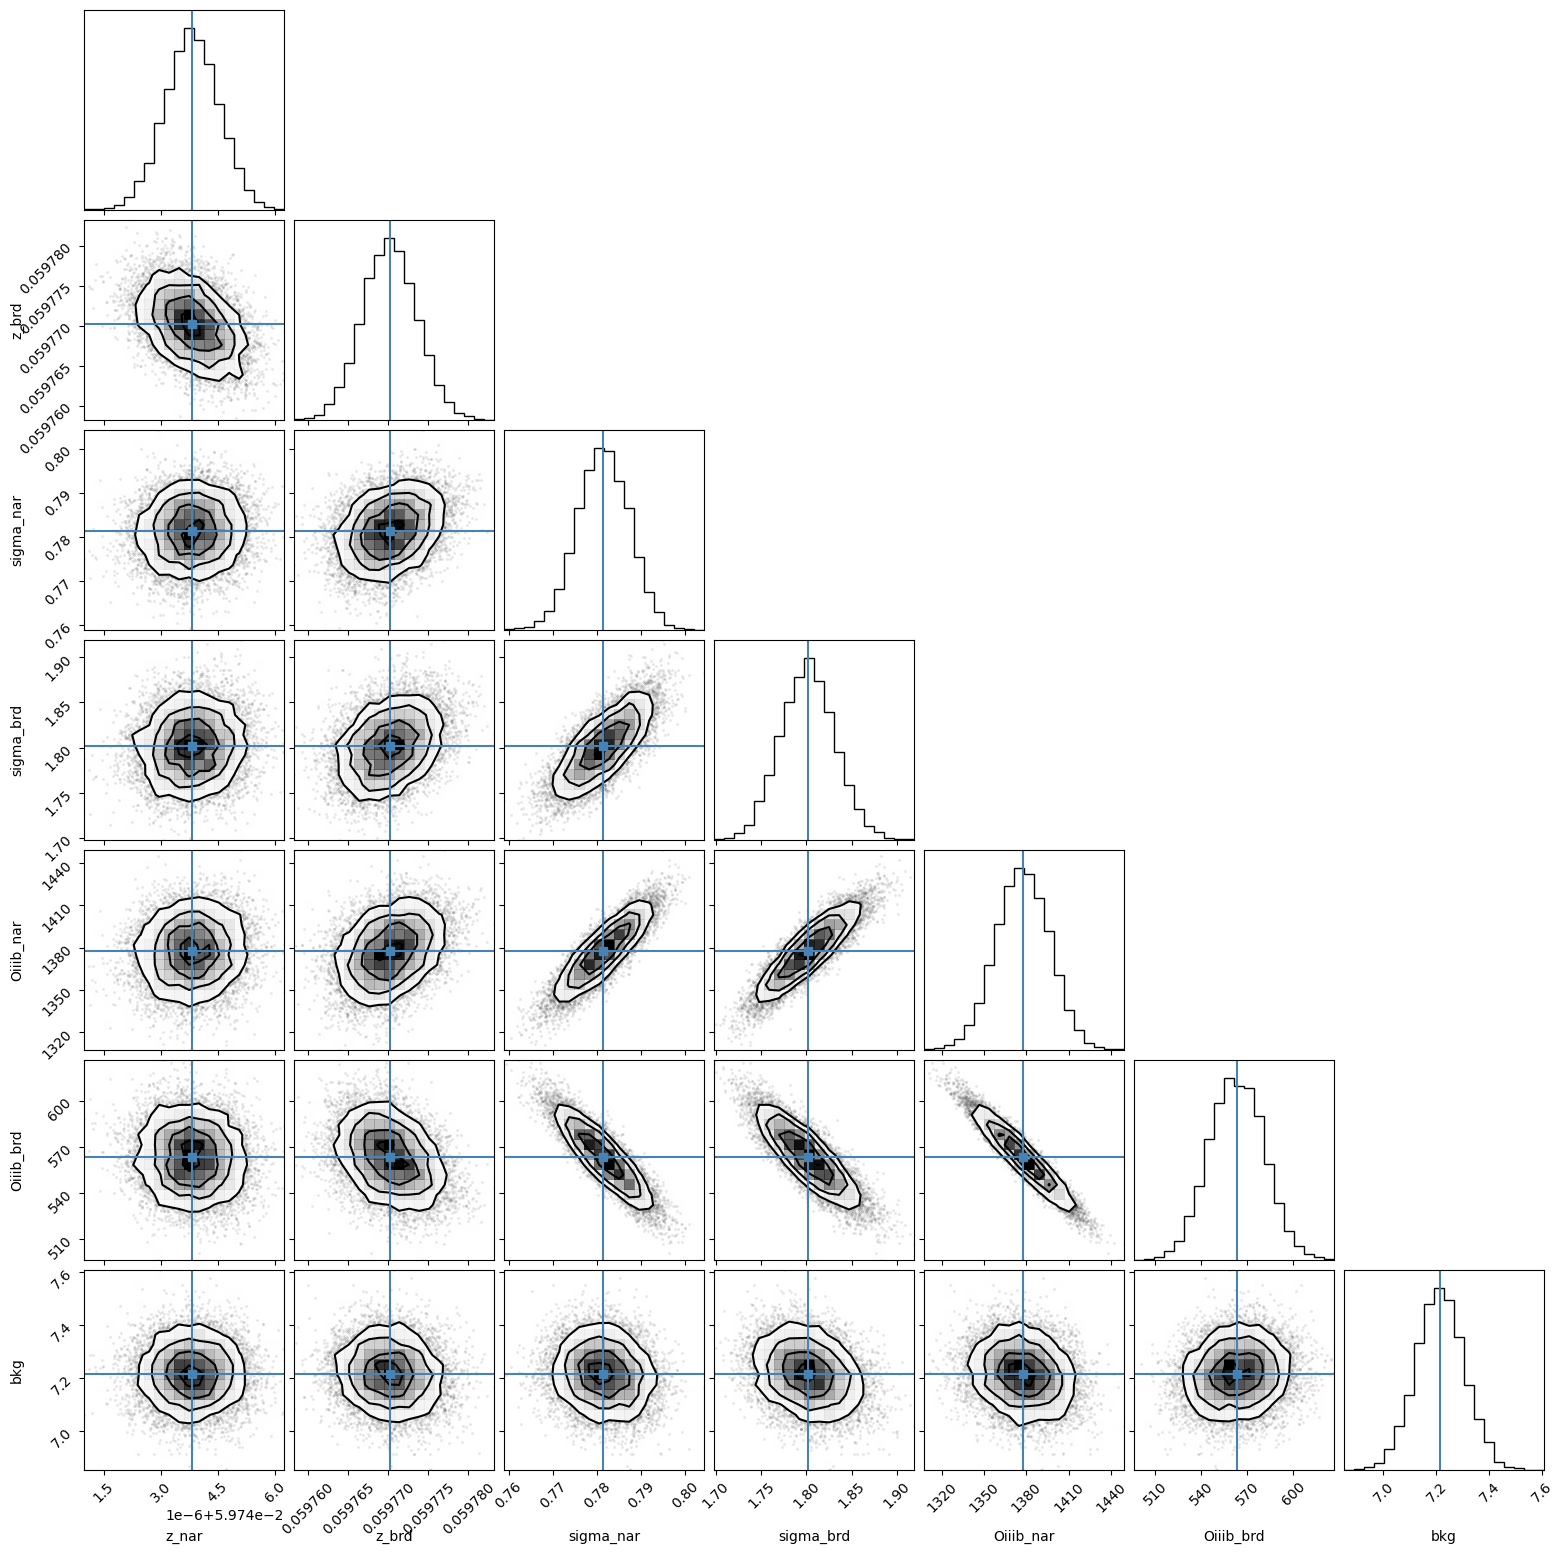

In [14]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig('/home/benjamin/Desktop/corner_oiiib.png')

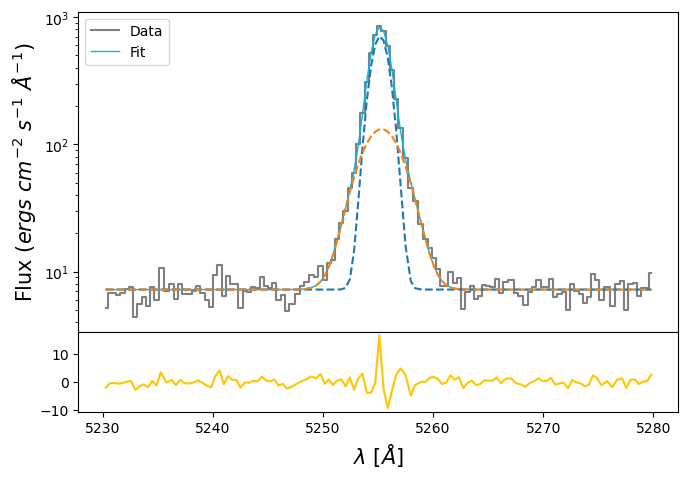

In [15]:
oiiib_nar_flux = out2_oiii_4959.params['Oiiib_nar'].value
oiiib_nar_std = out2_oiii_4959.params['Oiiib_nar'].stderr

oiiib_brd_flux = out2_oiii_4959.params['Oiiib_brd'].value
oiiib_brd_std = out2_oiii_4959.params['Oiiib_brd'].stderr

bkg_oiii_4959 = out2_oiii_4959.params['bkg'].value
bkg_oiii_4959_std = out2_oiii_4959.params['bkg'].stderr

z_nar_oiii_4959 = out2_oiii_4959.params['z_nar'].value
z_nar_oiii_4959_std = out2_oiii_4959.params['z_nar'].stderr

z_brd_oiii_4959 = out2_oiii_4959.params['z_brd'].value
z_brd_oiii_4959_std = out2_oiii_4959.params['z_brd'].stderr

sigma_nar_oiii_4959 = out2_oiii_4959.params['sigma_nar'].value
sigma_nar_oiii_4959_std = out2_oiii_4959.params['sigma_nar'].stderr

sigma_brd_oiii_4959 = out2_oiii_4959.params['sigma_brd'].value
sigma_brd_oiii_4959_std = out2_oiii_4959.params['sigma_brd'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.legend(loc='upper left')
ax.set_yscale('log')

In [16]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2)) 

In [17]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [18]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.0597+/-0.0000


In [19]:
# Velocities
vel = {'galname': galname,
       'z_nar': z_nar_oiii_4959,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}
vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
vel_catalog_pd

,galname,z_nar,dV,dV_err,FWHM_nar,FWHM_nar_err,FWHM_brd,FWHM_brd_err
0,J0136,0.059744,7.44508,1.436703,104.958949,1.045557,217.107295,6.162504


In [20]:
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J0136, overwriting...
Done.


---

# [NII]6548 + H$\alpha$ + [NII]6584

In [21]:
sigma_arc_ha = (m * wave_cat['Ha']*(1 + z_BN[igal])) + n

sigma_nar_ha = sigma_arc_ha
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

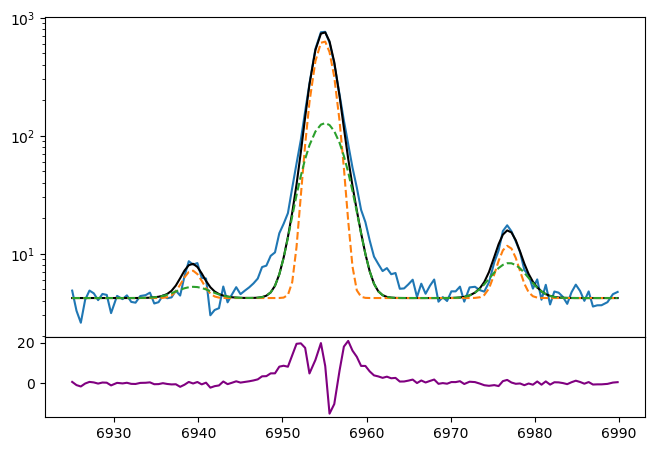

In [22]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 4.2

ha_nar = gaussian(ha_nii.wavelength, 17e2, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 6e2, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 0.8e1, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 0.5e1, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 2e1, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 2e1, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')

#ax.axvline(7175)
#ax.axvline(7247)
ax.set_yscale('log')

In [23]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_6584_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_6584_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('sigma_ha_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_ha_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('sigma_6548_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_6548_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=1.7e3, min=0.)
params_ha_nii.add('Ha_brd', value=0.6e3, min=0.)
params_ha_nii.add('Niia_nar', value=0.2e2, min=0.)
params_ha_nii.add('Niia_brd', value=0., vary=False)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=4.2, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_6584_nar = params_ha_nii['sigma_6584_nar']
    sigma_6584_brd = params_ha_nii['sigma_6584_brd']
    sigma_ha_nar = params_ha_nii['sigma_ha_nar']
    sigma_ha_brd = params_ha_nii['sigma_ha_brd']
    sigma_6548_nar = params_ha_nii['sigma_6548_nar']
    sigma_6548_brd = params_ha_nii['sigma_6548_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_ha_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_ha_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_6584_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_6584_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_6548_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_6548_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [24]:
np.random.seed(136)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:17<00:00, 146.58it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 48.38574099 109.26764018 111.4738344  102.68897393  38.96186284
  30.55317478]


In [25]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973945,4.3497e-07,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_6584_nar,1.07080981,,,1.070809806623744,-inf,inf,False
sigma_6584_brd,1.93921192,,,1.9392119226681903,-inf,inf,False
sigma_ha_nar,1.07080981,,,1.070809806623744,-inf,inf,False
sigma_ha_brd,1.93921192,,,1.9392119226681903,-inf,inf,False
sigma_6548_nar,1.07080981,,,1.070809806623744,-inf,inf,False
sigma_6548_brd,1.93921192,,,1.9392119226681903,-inf,inf,False
Ha_nar,1499.99913,7.76942138,(0.52%),1700.0,0.00000000,inf,True
Ha_brd,886.804091,7.89001654,(0.89%),600.0,0.00000000,inf,True


In [26]:
np.random.seed(136)
out2_ha_nii = minimize(residual_ha_nii, out_ha_nii.params, args=(1, 1, 1),
                      method='leastsq')

In [27]:
out2_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973944,1.2681e-06,(0.00%),0.059739446084269995,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_6584_nar,1.07080981,0.00000000,(0.00%),1.070809806623744,-inf,inf,False
sigma_6584_brd,1.93921192,0.00000000,(0.00%),1.9392119226681903,-inf,inf,False
sigma_ha_nar,1.07080981,0.00000000,(0.00%),1.070809806623744,-inf,inf,False
sigma_ha_brd,1.93921192,0.00000000,(0.00%),1.9392119226681903,-inf,inf,False
sigma_6548_nar,1.07080981,0.00000000,(0.00%),1.070809806623744,-inf,inf,False
sigma_6548_brd,1.93921192,0.00000000,(0.00%),1.9392119226681903,-inf,inf,False
Ha_nar,1500.25727,22.3117173,(1.49%),1499.999127250822,0.00000000,inf,True
Ha_brd,886.547210,22.5515564,(2.54%),886.8040908468145,0.00000000,inf,True


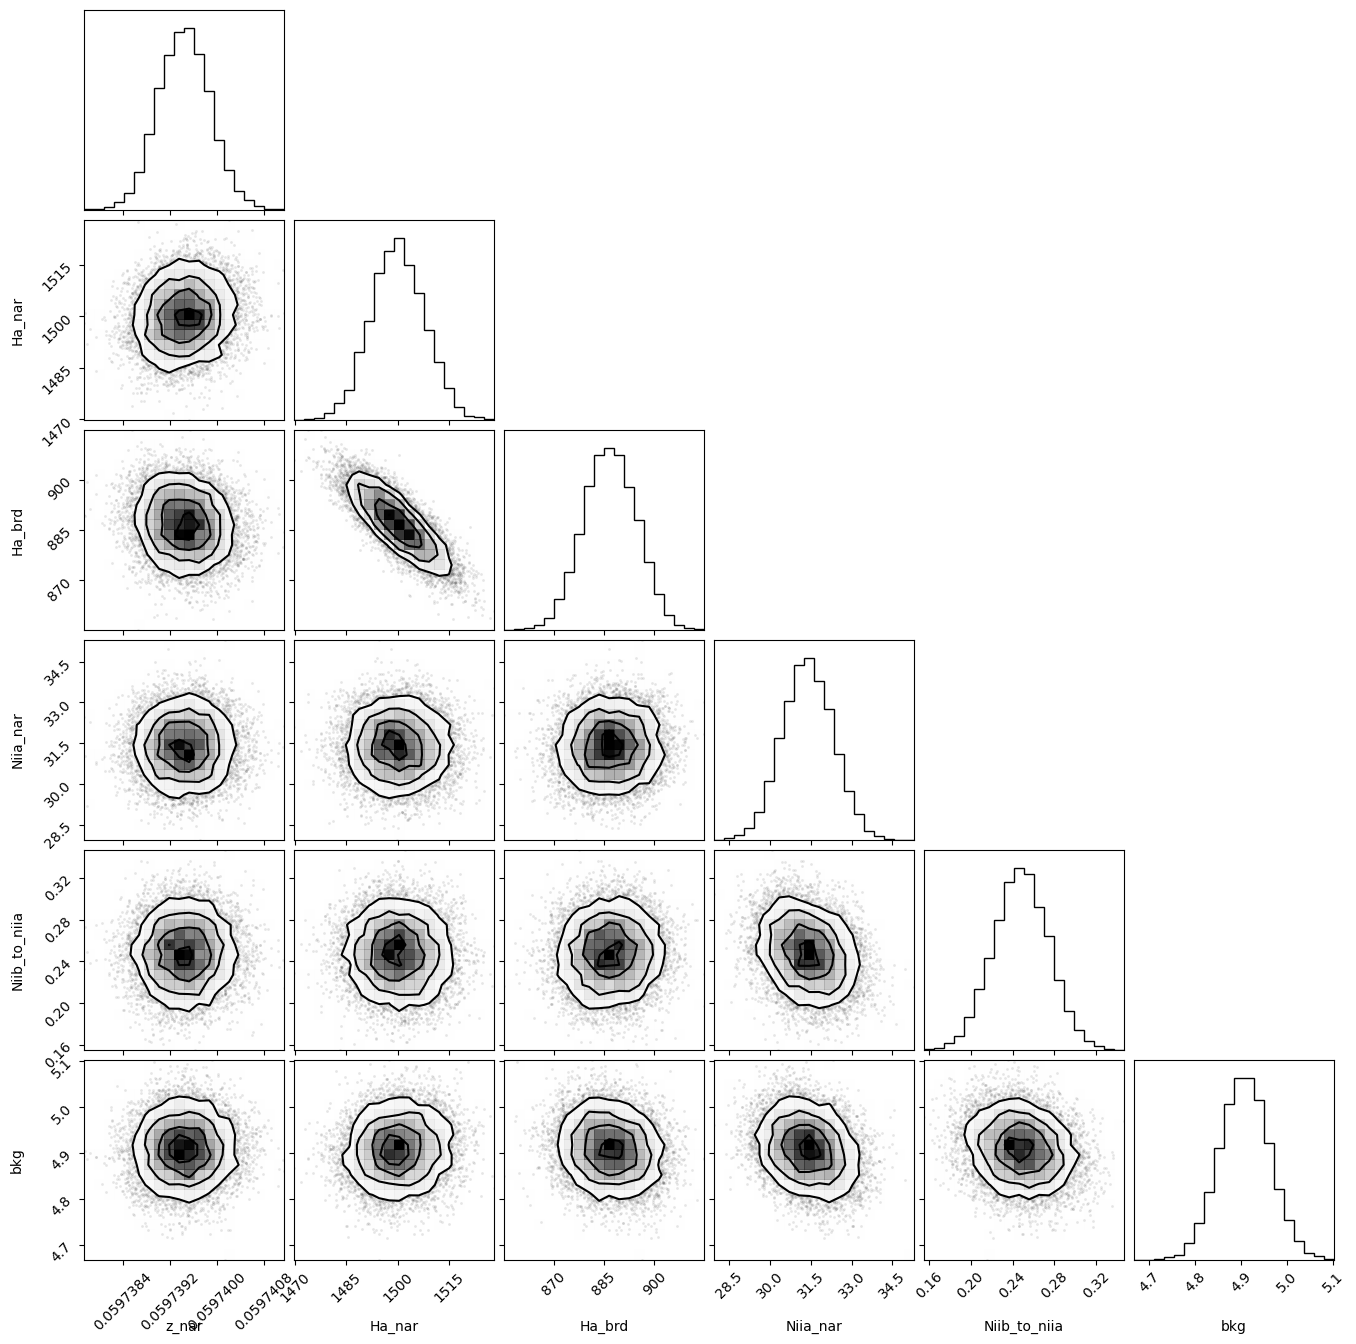

In [28]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

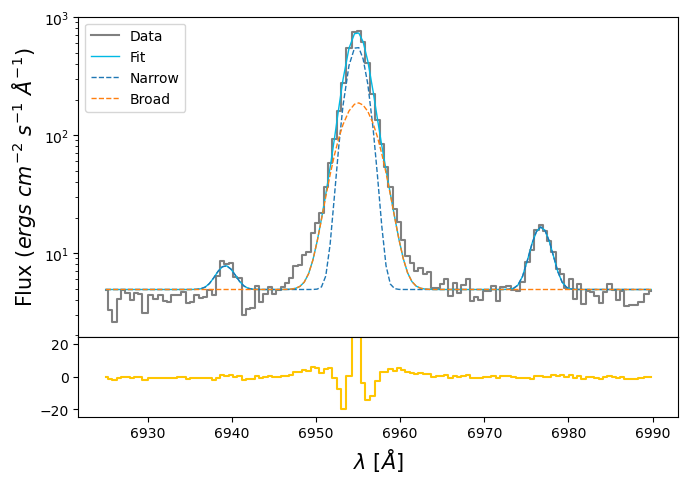

In [29]:
ha_nar_flux = out2_ha_nii.params['Ha_nar'].value
ha_nar_std = out2_ha_nii.params['Ha_nar'].stderr

ha_brd_flux = out2_ha_nii.params['Ha_brd'].value
ha_brd_std = out2_ha_nii.params['Ha_brd'].stderr

niia_nar_flux = out2_ha_nii.params['Niia_nar'].value
niia_nar_std = out2_ha_nii.params['Niia_nar'].stderr

niia_brd_flux = out2_ha_nii.params['Niia_brd'].value
niia_brd_std = out2_ha_nii.params['Niia_brd'].stderr

niib_nar_flux = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].value
niib_nar_std = niia_nar_flux * out_ha_nii.params['Niib_to_niia'].stderr

niib_brd_flux = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].value
niib_brd_std = niia_brd_flux * out_ha_nii.params['Niib_to_niia'].stderr

z_ha_nii = out_ha_nii.params['z_nar'].value
z_ha_nii_std = out_ha_nii.params['z_nar'].stderr

bkg_ha_nii = out_ha_nii.params['bkg'].value
bkg_ha_nii_std = out_ha_nii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [30]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

# [OII]7319 + [OII]7330

In [31]:
sigma_arc_7330 = (m * wave_cat['[OII]7330']*(1 + z_BN[igal])) + n

sigma_nar_7330 = sigma_arc_7330
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

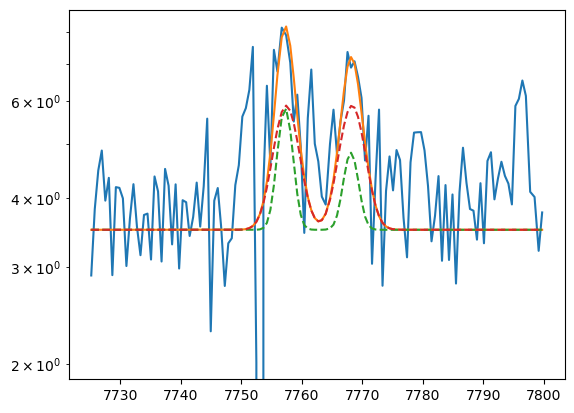

In [32]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 0.4e1, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 1.2e1, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 0.7e1, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 1.2e1, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 3.5

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [33]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=0., vary=False)
params_oii_7320.add('Oiia_brd', value=1.2e1, min=0.)
params_oii_7320.add('Oiib_nar', value=0., vary=False)
params_oii_7320.add('Oiib_brd', value=1.2e1, min=0.)
params_oii_7320.add('bkg', value=3.5, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [34]:
np.random.seed(136)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:12<00:00, 193.16it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.57463599 49.69993182 64.3991745  37.02382209]


In [35]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05969598,2.2394e-05,(0.04%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,1.20144940,,,1.201449399248384,-inf,inf,False
sigma_brd,2.01429638,,,2.0142963778975482,-inf,inf,False
Oiia_nar,0.00000000,,,0.0,-inf,inf,False
Oiia_brd,14.4375338,1.20060143,(8.32%),12.0,0.00000000,inf,True
Oiib_nar,0.00000000,,,0.0,-inf,inf,False
Oiib_brd,18.1301124,1.48514003,(8.19%),12.0,0.00000000,inf,True
bkg,3.97134090,0.06073013,(1.53%),3.5,0.00000000,inf,True


In [36]:
np.random.seed(136)
out2_oii_7320 = minimize(residual_oii_7320, out_oii_7320.params, args=(1, 1, 1),
                         method='leastsq')

In [37]:
out2_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05969640,3.0426e-05,(0.05%),0.05969597698901128,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,1.20144940,0.00000000,(0.00%),1.201449399248384,-inf,inf,False
sigma_brd,2.01429638,0.00000000,(0.00%),2.0142963778975482,-inf,inf,False
Oiia_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiia_brd,14.4770579,1.61742216,(11.17%),14.437533824308083,0.00000000,inf,True
Oiib_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Oiib_brd,18.1298157,1.98113723,(10.93%),18.130112449944313,0.00000000,inf,True
bkg,3.96967368,0.07985703,(2.01%),3.9713408988327044,0.00000000,inf,True


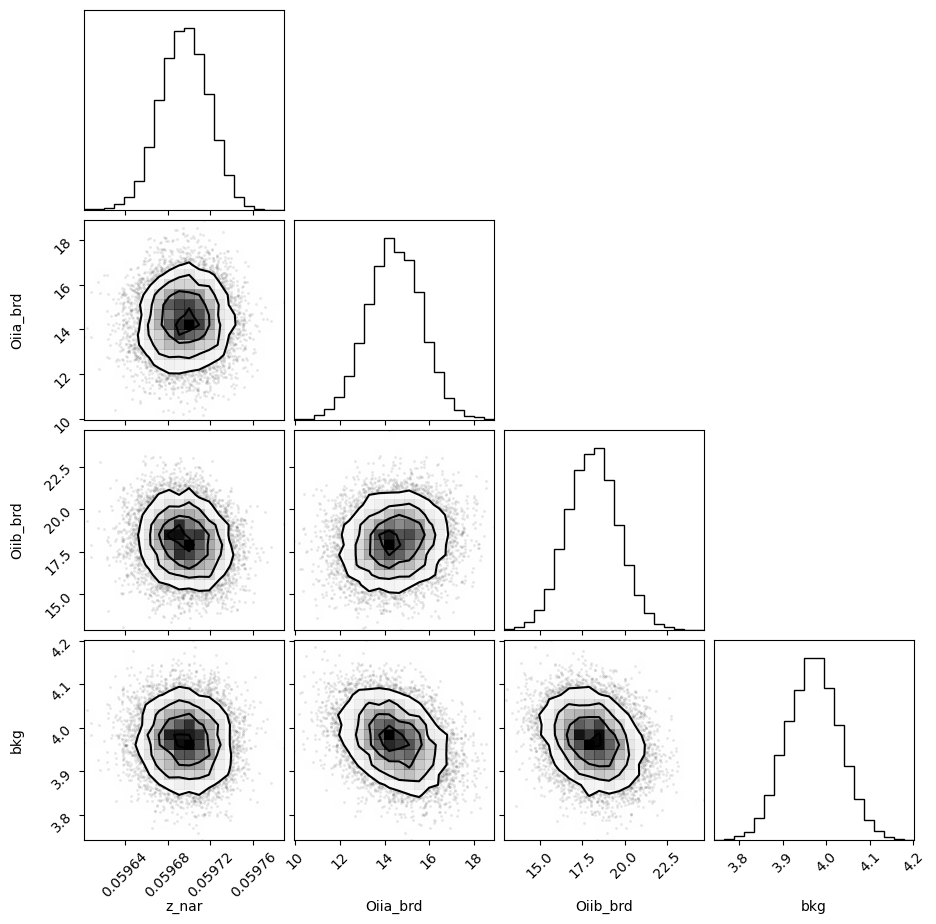

In [38]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_oii_7330.png')

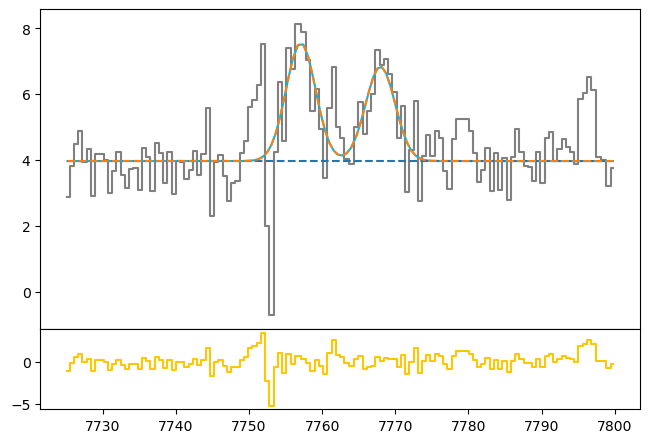

In [39]:
oiia_nar_flux = out2_oii_7320.params['Oiia_nar'].value
oiia_nar_std = out2_oii_7320.params['Oiia_nar'].stderr

oiia_brd_flux = out2_oii_7320.params['Oiia_brd'].value
oiia_brd_std = out2_oii_7320.params['Oiia_brd'].stderr

oiib_nar_flux = out2_oii_7320.params['Oiib_nar'].value
oiib_nar_std = out2_oii_7320.params['Oiib_nar'].stderr

oiib_brd_flux = out2_oii_7320.params['Oiib_brd'].value
oiib_brd_std = out2_oii_7320.params['Oiib_brd'].stderr

z_oii_7320 = out2_oii_7320.params['z_nar'].value
z_oii_7320_std = out2_oii_7320.params['z_nar'].stderr

bkg_oii_7320 = out2_oii_7320.params['bkg'].value
bkg_oii_7320_std = out2_oii_7320.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

In [40]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

# [SII]6716 + [SII]6730

In [41]:
sigma_arc_6730 = (m * wave_cat['[SII]6730']*(1 + z_BN[igal])) + n

sigma_nar_6730 = sigma_arc_6730
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

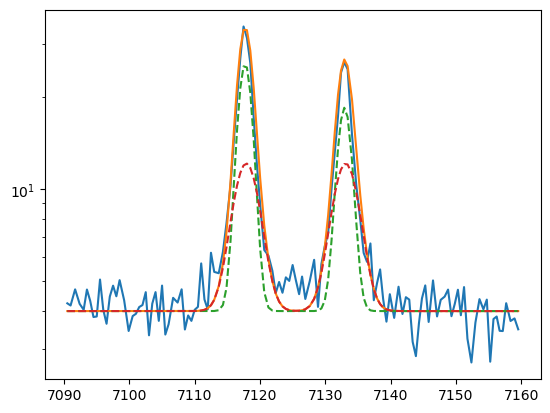

In [42]:
plt.plot(sii.wavelength, sii.flux)
bkg = 4

siia_nar = gaussian(sii.wavelength, 4e1, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 4e1, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 6e1, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 4e1, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [43]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=4.0e1, min=0.)
params_sii.add('Siia_brd', value=0., vary=False)
params_sii.add('Siib_nar', value=6.0e1, min=0.)
params_sii.add('Siib_brd', value=0., vary=False)
params_sii.add('bkg', value=4, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [44]:
np.random.seed(136)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:13<00:00, 185.88it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [40.16766572 67.20980467 65.12763879 63.76155148]


In [45]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973659,2.7093e-06,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,1.09941382,,,1.099413816984384,-inf,inf,False
sigma_brd,1.95515216,,,1.9551521628847848,-inf,inf,False
Siia_nar,58.8280685,1.17817185,(2.00%),40.0,0.00000000,inf,True
Siia_brd,0.00000000,,,0.0,-inf,inf,False
Siib_nar,79.5797563,1.29253198,(1.62%),60.0,0.00000000,inf,True
Siib_brd,0.00000000,,,0.0,-inf,inf,False
bkg,4.45438567,0.05353575,(1.20%),4,0.00000000,inf,True


In [46]:
np.random.seed(136)
out2_sii = minimize(residual_sii, out_sii.params, args=(1, 1, 1),
                    method='leastsq')

In [47]:
out2_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973673,3.6364e-06,(0.01%),0.05973658878920835,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,1.09941382,0.00000000,(0.00%),1.099413816984384,-inf,inf,False
sigma_brd,1.95515216,0.00000000,(0.00%),1.9551521628847848,-inf,inf,False
Siia_nar,58.7677362,1.67852980,(2.86%),58.828068454267,0.00000000,inf,True
Siia_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
Siib_nar,79.5922860,1.82743134,(2.30%),79.57975633205884,0.00000000,inf,True
Siib_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,4.45399953,0.07651756,(1.72%),4.4543856730445555,0.00000000,inf,True


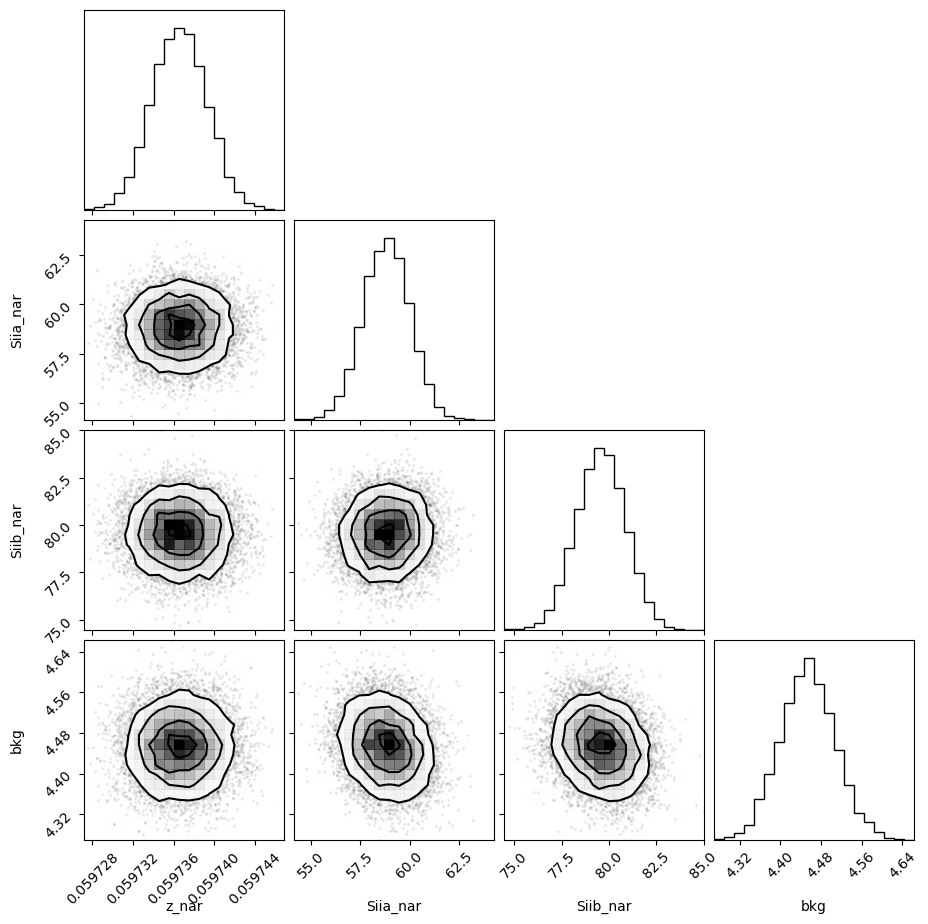

In [48]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_sii_6717.png')

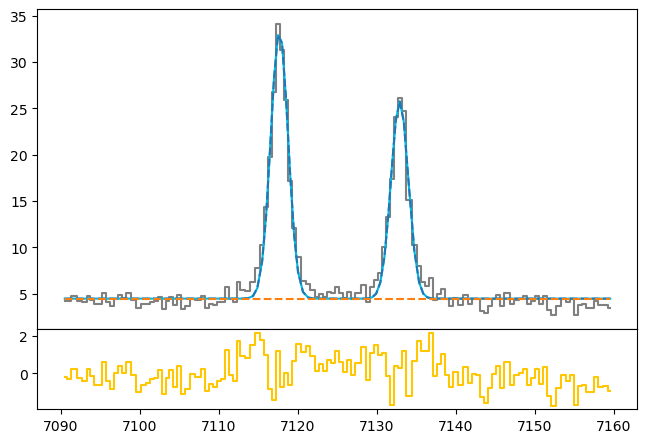

In [49]:
siia_nar_flux = out2_sii.params['Siia_nar'].value
siia_nar_std = out2_sii.params['Siia_nar'].stderr

siia_brd_flux = out2_sii.params['Siia_brd'].value
siia_brd_std = out2_sii.params['Siia_brd'].stderr

siib_nar_flux = out2_sii.params['Siib_nar'].value
siib_nar_std = out2_sii.params['Siib_nar'].stderr

siib_brd_flux = out2_sii.params['Siib_brd'].value
siib_brd_std = out2_sii.params['Siib_brd'].stderr

z_sii = out2_sii.params['z_nar'].value
z_sii_std = out2_sii.params['z_nar'].stderr

bkg_sii = out2_sii.params['bkg'].value
bkg_sii_std = out2_sii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')

In [50]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

# H$\beta$

In [51]:
sigma_arc_hb = (m * wave_cat['Hb']*(1 + z_BN[igal])) + n

sigma_nar_hb = sigma_arc_hb
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

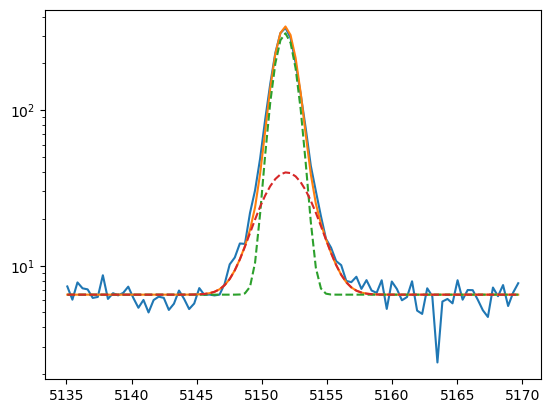

In [52]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 6.5

hb_nar = gaussian(hbeta.wavelength, 6e2, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 1.5e2, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [53]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=6.0e2, min=0.)
params_hb.add('Hb_brd', value=1.5e2, min=0.)
params_hb.add('bkg', value=6.5, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [54]:
np.random.seed(136)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 275.28it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [33.82238683 81.25841607 83.35438272 43.79586595]


In [55]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973509,8.7861e-07,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.78116239,,,0.7811623887513601,-inf,inf,False
sigma_brd,1.79558456,,,1.7955845612659433,-inf,inf,False
Hb_nar,555.224865,4.04732721,(0.73%),600.0,0.00000000,inf,True
Hb_brd,212.285508,4.33205817,(2.04%),150.0,0.00000000,inf,True
bkg,6.38416019,0.09027116,(1.41%),6.5,0.00000000,inf,True


In [56]:
np.random.seed(136)
out2_hb = minimize(residual_hb, out_hb.params, args=(1, 1, 1),
                   method='leastsq')

In [57]:
out2_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973509,1.1927e-06,(0.00%),0.05973508538398879,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.78116239,0.00000000,(0.00%),0.7811623887513601,-inf,inf,False
sigma_brd,1.79558456,0.00000000,(0.00%),1.7955845612659433,-inf,inf,False
Hb_nar,555.007419,5.45686832,(0.98%),555.2248649158066,0.00000000,inf,True
Hb_brd,212.483251,5.85739364,(2.76%),212.28550814697144,0.00000000,inf,True
bkg,6.38227260,0.12222960,(1.92%),6.384160188614452,0.00000000,inf,True


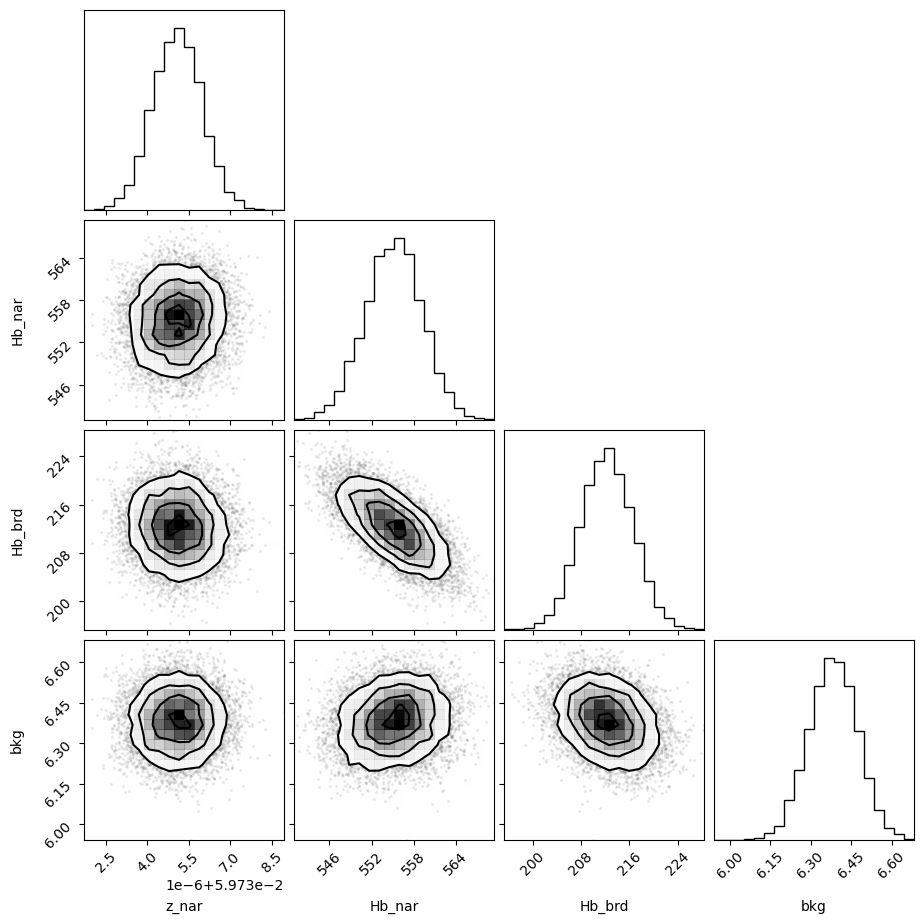

In [58]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

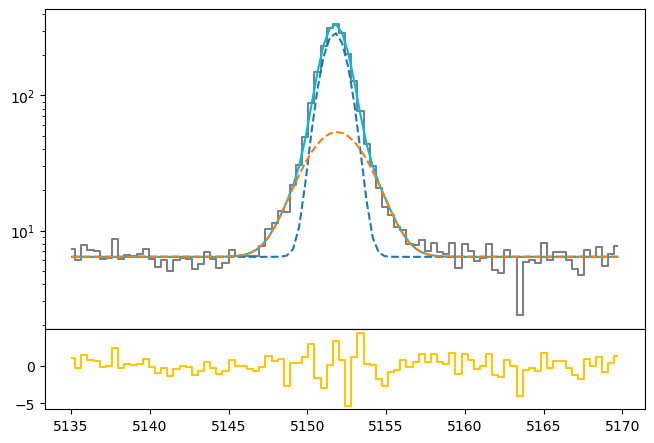

In [59]:
hb_nar_flux = out2_hb.params['Hb_nar'].value
hb_nar_std = out2_hb.params['Hb_nar'].stderr

hb_brd_flux = out2_hb.params['Hb_brd'].value
hb_brd_std = out2_hb.params['Hb_brd'].stderr

z_hb = out2_hb.params['z_nar'].value
z_hb_std = out2_hb.params['z_nar'].stderr

bkg_hb = out2_hb.params['bkg'].value
bkg_hb_std = out2_hb.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

In [60]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

# H$\gamma$

In [61]:
sigma_arc_hg = (m * wave_cat['Hg']*(1 + z_BN[igal])) + n

sigma_nar_hg = sigma_arc_hg
sigma_brd_hg = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hg**2))

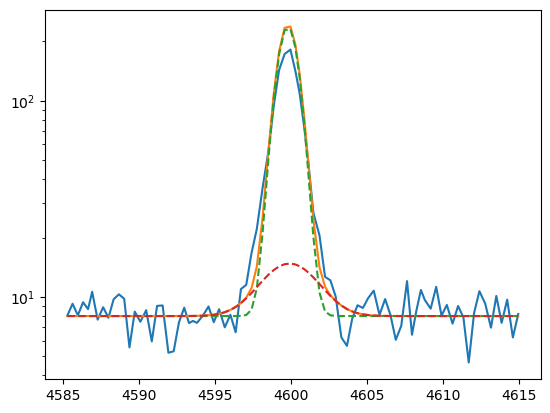

In [62]:
plt.plot(hgamma.wavelength, hgamma.flux)
bkg = 8

hg_nar = gaussian(hgamma.wavelength, 4e2, wave_cat['Hg'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, 3e1, wave_cat['Hg'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

plt.plot(hgamma.wavelength, hg + bkg)
plt.plot(hgamma.wavelength, hg_nar + bkg, ls='--')
plt.plot(hgamma.wavelength, hg_brd + bkg, ls='--')
plt.yscale('log')

In [63]:
params_hg = Parameters()
params_hg.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hg.add('z_ratio', value=z_ratio, vary=False)
params_hg.add('sigma_nar', value=upy.nominal_values(sigma_nar_hg), vary=False)
params_hg.add('sigma_brd', value=upy.nominal_values(sigma_brd_hg), vary=False)
params_hg.add('Hg_nar', value=3.5e2, min=0.)
params_hg.add('Hg_brd', value=3.0e1, min=0.)
params_hg.add('bkg', value=8, min=0.)

def residual_hg(params_hg, x, data, uncertainty):
    
    z_nar = params_hg['z_nar']
    z_brd = params_hg['z_nar'] * params_hg['z_ratio']
    sigma_nar = params_hg['sigma_nar']
    sigma_brd = params_hg['sigma_brd']
    hg_nar_flux = params_hg['Hg_nar']
    hg_brd_flux = params_hg['Hg_brd']
    bkg = params_hg['bkg']
    
    x = hgamma.wavelength
    model = gaussian(x, hg_nar_flux, wave_cat['Hg'], z_nar, sigma_nar) + \
            gaussian(x, hg_brd_flux, wave_cat['Hg'], z_brd, sigma_brd)
    return (model + bkg - hgamma.flux) / hgamma.noise

In [64]:
np.random.seed(136)
out_hg = minimize(residual_hg, params_hg, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 266.31it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [41.97185064 81.70664486 94.08485026 43.03131672]


In [65]:
out_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973707,1.9607e-06,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.69248987,,,0.6924898715150591,-inf,inf,False
sigma_brd,1.75882104,,,1.758821042973907,-inf,inf,False
Hg_nar,273.153031,4.07590237,(1.49%),350.0,0.00000000,inf,True
Hg_brd,87.3332860,5.27721941,(6.04%),30.0,0.00000000,inf,True
bkg,7.96527484,0.18188658,(2.28%),8,0.00000000,inf,True


In [66]:
np.random.seed(136)
out2_hg = minimize(residual_hg, out_hg.params, args=(1, 1, 1),
                   method='leastsq')

In [67]:
out2_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973711,2.4965e-06,(0.00%),0.05973707218662917,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.69248987,0.00000000,(0.00%),0.6924898715150591,-inf,inf,False
sigma_brd,1.75882104,0.00000000,(0.00%),1.758821042973907,-inf,inf,False
Hg_nar,273.135930,5.29132582,(1.94%),273.1530314469064,0.00000000,inf,True
Hg_brd,87.2608986,6.92194742,(7.93%),87.33328597449332,0.00000000,inf,True
bkg,7.97101973,0.23659643,(2.97%),7.965274844050976,0.00000000,inf,True


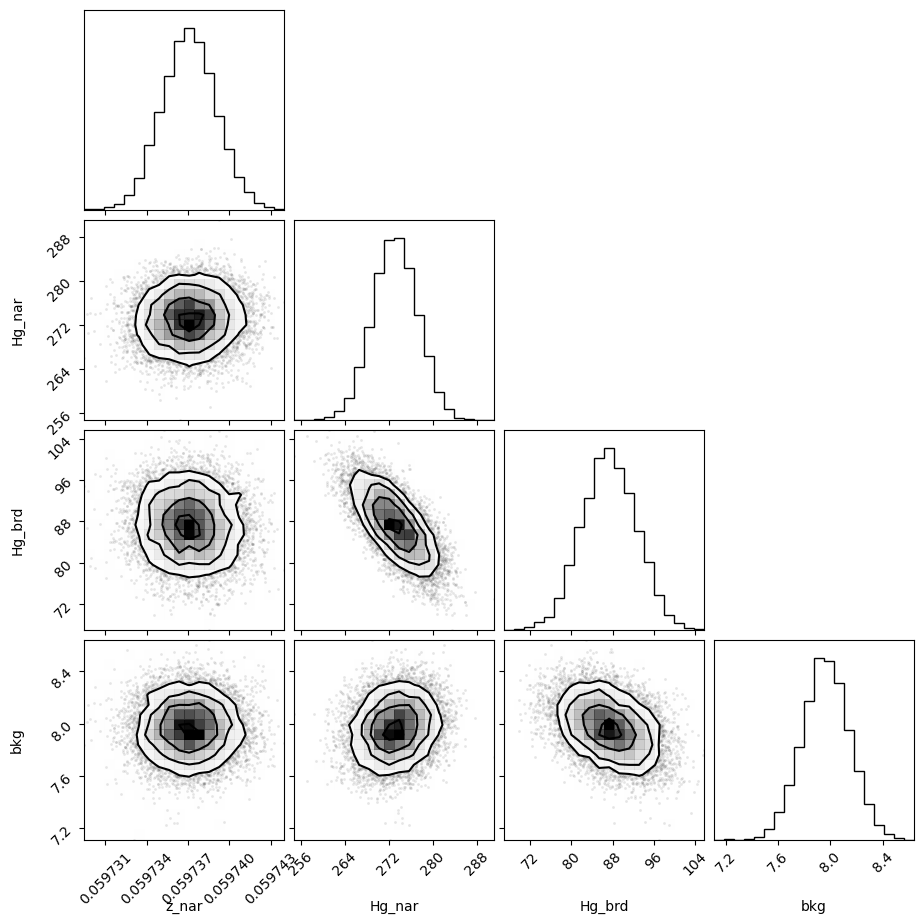

In [68]:
corner.corner(out_hg.flatchain, labels=out_hg.var_names);

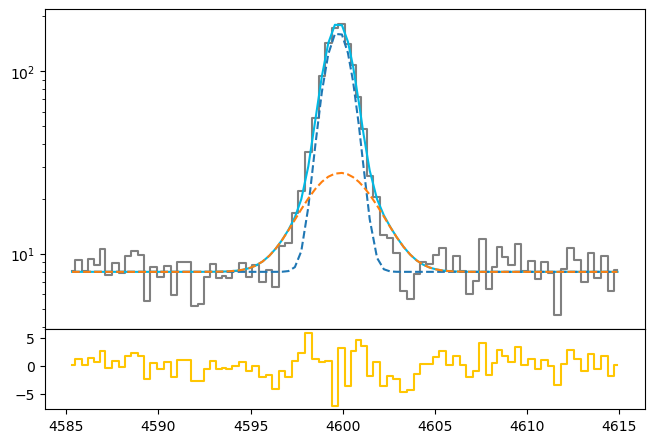

In [69]:
hg_nar_flux = out2_hg.params['Hg_nar'].value
hg_nar_std = out2_hg.params['Hg_nar'].stderr

hg_brd_flux = out2_hg.params['Hg_brd'].value
hg_brd_std = out2_hg.params['Hg_brd'].stderr

z_hg = out2_hg.params['z_nar'].value
z_hg_std = out2_hg.params['z_nar'].stderr

bkg_hg = out2_hg.params['bkg'].value
bkg_hg_std = out2_hg.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hgamma.wavelength, hgamma.flux, color='gray', label='Data', where='mid')

hg_nar = gaussian(hgamma.wavelength, hg_nar_flux, wave_cat['Hg'],           z_hg, upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, hg_brd_flux, wave_cat['Hg'], z_hg * z_ratio, upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

ax.plot(hgamma.wavelength, bkg_hg + hg, color=c[0])
ax.plot(hgamma.wavelength, bkg_hg + hg_nar, ls='--')
ax.plot(hgamma.wavelength, bkg_hg + hg_brd, ls='--')
ax.set_yscale('log')
ax1.step(hgamma.wavelength, hgamma.flux - bkg_hg - hg, color=c[3], where='mid')

In [70]:
# EW
EW_Hg_nar = ufloat(hg_nar_flux, hg_nar_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg_brd = ufloat(hg_brd_flux, hg_brd_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg = (ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / ufloat(bkg_hg, bkg_hg_std)

# H$\delta$

In [71]:
sigma_arc_hd = (m * wave_cat['Hd']*(1 + z_BN[igal])) + n

sigma_nar_hd = sigma_arc_hd
sigma_brd_hd = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hd**2))

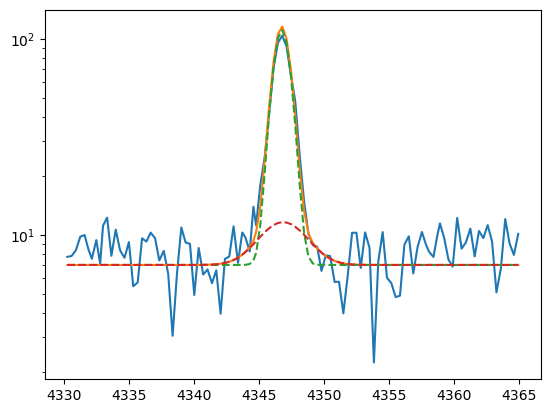

In [72]:
plt.plot(hdelta.wavelength, hdelta.flux)
bkg = 7

hd_nar = gaussian(hdelta.wavelength, 1.7e2, wave_cat['Hd'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hd))
hd_brd = gaussian(hdelta.wavelength, 2e1, wave_cat['Hd'], z=z_brd_oiii_4959,   sigma=upy.nominal_values(sigma_brd_hd))

hd = hd_nar + hd_brd

plt.plot(hdelta.wavelength, hd + bkg)
plt.plot(hdelta.wavelength, hd_nar + bkg, ls='--')
plt.plot(hdelta.wavelength, hd_brd + bkg, ls='--')
plt.yscale('log')

In [73]:
params_hd = Parameters()
params_hd.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hd.add('z_ratio', value=z_ratio, vary=False)
params_hd.add('sigma_nar', value=upy.nominal_values(sigma_nar_hd), vary=False)
params_hd.add('sigma_brd', value=upy.nominal_values(sigma_brd_hd), vary=False)
params_hd.add('Hd_nar', value=1.7e2, min=0.)
params_hd.add('Hd_brd', value=2.0e1, min=0.)
params_hd.add('bkg', value=7, min=0.)

def residual_hd(params_hd, x, data, uncertainty):
    
    z_nar = params_hd['z_nar']
    z_brd = params_hd['z_nar'] * params_hd['z_ratio']
    sigma_nar = params_hd['sigma_nar']
    sigma_brd = params_hd['sigma_brd']
    hd_nar_flux = params_hd['Hd_nar']
    hd_brd_flux = params_hd['Hd_brd']
    bkg = params_hd['bkg']
    
    x = hdelta.wavelength
    model = gaussian(x, hd_nar_flux, wave_cat['Hd'], z_nar, sigma_nar) + \
            gaussian(x, hd_brd_flux, wave_cat['Hd'], z_brd, sigma_brd)
    return (model + bkg - hdelta.flux) / hdelta.noise

In [74]:
np.random.seed(136)
out_hd = minimize(residual_hd, params_hd, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 273.94it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.95153698 57.79085919 49.2846459  43.31527166]


In [75]:
out_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05975015,3.1361e-06,(0.01%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.65184388,,,0.6518438795590035,-inf,inf,False
sigma_brd,1.74321820,,,1.7432181970067349,-inf,inf,False
Hd_nar,148.974568,3.46518283,(2.33%),170.0,0.00000000,inf,True
Hd_brd,28.9058442,5.00590007,(17.32%),20.0,0.00000000,inf,True
bkg,7.93258086,0.17674442,(2.23%),7,0.00000000,inf,True


In [76]:
np.random.seed(136)
out2_hd = minimize(residual_hd, out_hd.params, args=(1, 1, 1),
                   method='leastsq')

In [77]:
out2_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05975012,4.0589e-06,(0.01%),0.059750145999758184,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.65184388,0.00000000,(0.00%),0.6518438795590035,-inf,inf,False
sigma_brd,1.74321820,0.00000000,(0.00%),1.7432181970067349,-inf,inf,False
Hd_nar,148.917461,4.49579862,(3.02%),148.97456844966416,0.00000000,inf,True
Hd_brd,28.9262893,6.42598649,(22.22%),28.90584424652684,0.00000000,inf,True
bkg,7.93440358,0.23227341,(2.93%),7.9325808629439685,0.00000000,inf,True


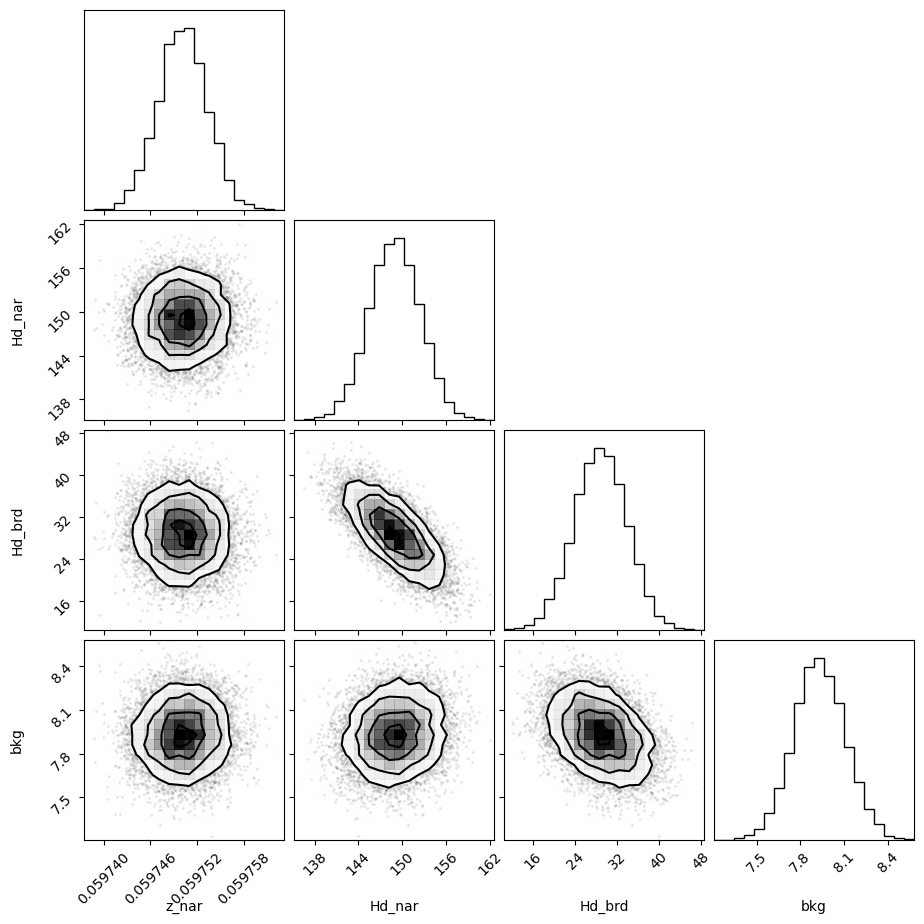

In [78]:
corner.corner(out_hd.flatchain, labels=out_hd.var_names);

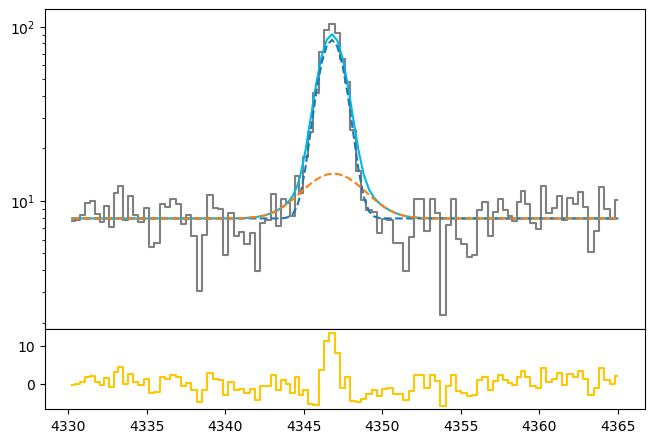

In [79]:
hd_nar_flux = out2_hd.params['Hd_nar'].value
hd_nar_std = out2_hd.params['Hd_nar'].stderr

hd_brd_flux = out2_hd.params['Hd_brd'].value
hd_brd_std = out2_hd.params['Hd_brd'].stderr

z_hd = out2_hd.params['z_nar'].value
z_hd_std = out2_hd.params['z_nar'].stderr

bkg_hd = out2_hd.params['bkg'].value
bkg_hd_std = out2_hd.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hdelta.wavelength, hdelta.flux, color='gray', label='Data', where='mid')

hd_nar = gaussian(hdelta.wavelength, hd_nar_flux, wave_cat['Hd'], z_hd, sigma_nar_oiii_4959)
hd_brd = gaussian(hdelta.wavelength, hd_brd_flux, wave_cat['Hd'], z_hd * z_ratio, sigma_brd_oiii_4959)

hd = hd_nar + hd_brd

ax.plot(hdelta.wavelength, bkg_hd + hd, color=c[0])
ax.plot(hdelta.wavelength, bkg_hd + hd_nar, ls='--')
ax.plot(hdelta.wavelength, bkg_hd + hd_brd, ls='--')
ax.set_yscale('log')
ax1.step(hdelta.wavelength, hdelta.flux - bkg_hd - hd, color=c[3], where='mid')

In [80]:
# EW
EW_Hd_nar = ufloat(hd_nar_flux, hd_nar_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd_brd = ufloat(hd_brd_flux, hd_brd_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd = (ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / ufloat(bkg_hd, bkg_hd_std)

# [OII]3726 + [OII]3729

In [81]:
sigma_arc_3729 = (m * wave_cat['[OII]3729']*(1 + z_BN[igal])) + n

sigma_nar_3729 = sigma_arc_3729
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

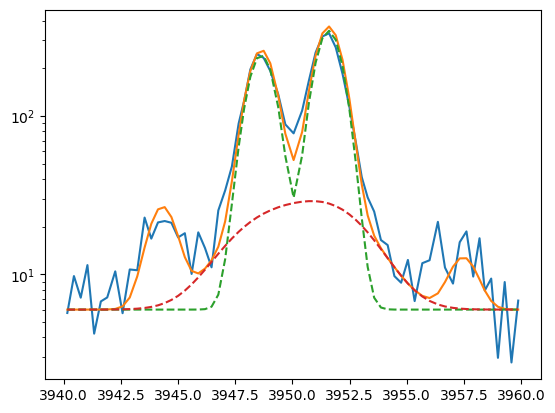

In [82]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 0.1e2, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 0.5e3, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 0.8e2, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 0.35e3, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 0.6e2, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 0.3e2, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 6

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [83]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=0.1e2, min=0.)
params_oii_3727.add('Oiic_nar', value=0.5e3, min=0.)
params_oii_3727.add('Oiic_brd', value=0.8e2, min=0.)
params_oii_3727.add('Oiid_nar', value=0.35e3, min=0.)
params_oii_3727.add('Oiid_brd', value=0.6e2, min=0.)
params_oii_3727.add('H14', value=0.3e2, min=0.)
params_oii_3727.add('bkg', value=6, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [84]:
np.random.seed(136)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:16<00:00, 155.41it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 55.47265896  66.68129864 102.89806794  92.40214349 145.27588126
 159.92600189 104.48739426  58.97682124]


In [85]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05972609,1.8359e-06,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.58836344,,,0.588363442917184,-inf,inf,False
sigma_brd,1.72048853,,,1.7204885294643035,-inf,inf,False
H13,13.6656762,2.53330564,(18.54%),10.0,0.00000000,inf,True
Oiic_nar,420.105694,6.54951017,(1.56%),500.0,0.00000000,inf,True
Oiic_brd,147.561356,10.0608636,(6.82%),80.0,0.00000000,inf,True
Oiid_nar,295.413841,6.16668860,(2.09%),350.0,0.00000000,inf,True
Oiid_brd,125.858637,10.1433954,(8.06%),60.0,0.00000000,inf,True
H14,23.2658317,2.54876409,(10.95%),30.0,0.00000000,inf,True


In [86]:
np.random.seed(136)
out2_oii_3727 = minimize(residual_oii_3727, out_oii_3727.params, args=(1, 1, 1),
                         method='leastsq')

In [87]:
out2_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05972611,2.6026e-06,(0.00%),0.059726085704845444,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.58836344,0.00000000,(0.00%),0.588363442917184,-inf,inf,False
sigma_brd,1.72048853,0.00000000,(0.00%),1.7204885294643035,-inf,inf,False
H13,13.7697057,3.51717366,(25.54%),13.665676168517482,0.00000000,inf,True
Oiic_nar,420.085059,9.20683096,(2.19%),420.1056942393173,0.00000000,inf,True
Oiic_brd,147.590941,14.2369192,(9.65%),147.56135569285124,0.00000000,inf,True
Oiid_nar,295.222766,8.71794022,(2.95%),295.41384088690364,0.00000000,inf,True
Oiid_brd,125.950786,14.4155321,(11.45%),125.85863677353609,0.00000000,inf,True
H14,23.2653708,3.59346008,(15.45%),23.26583170821713,0.00000000,inf,True


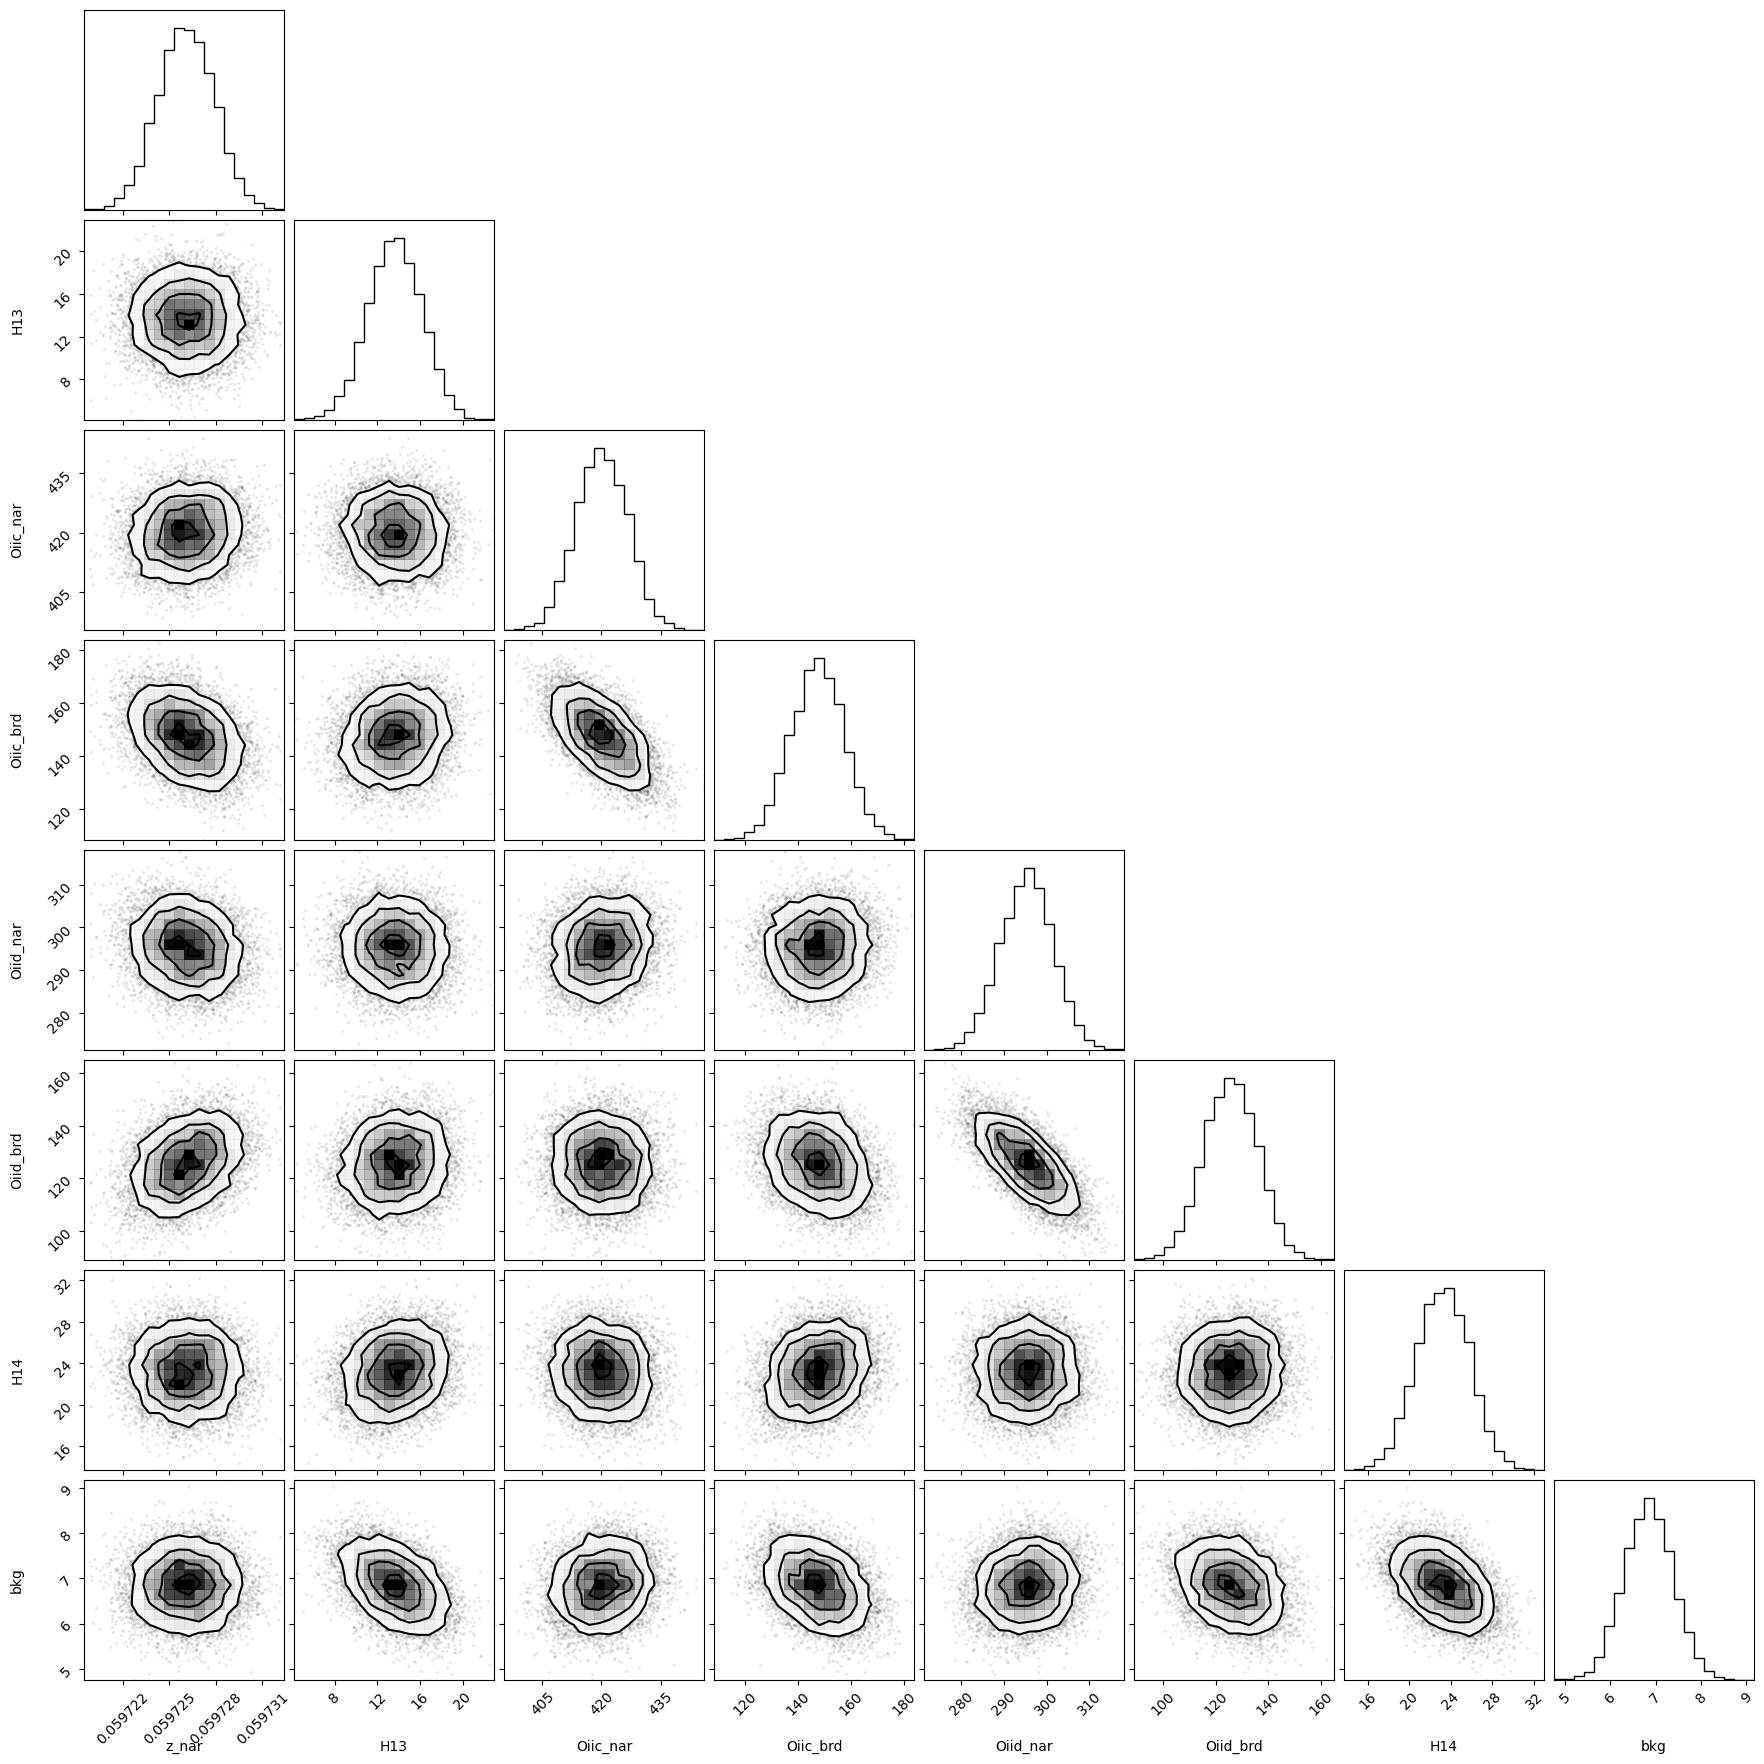

In [88]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_oii_3727.png')

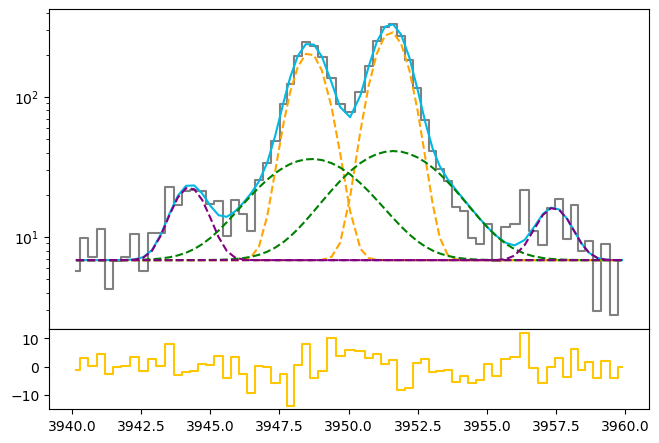

In [89]:
h13_flux = out2_oii_3727.params['H13'].value
h13_std = out2_oii_3727.params['H13'].stderr

oiic_nar_flux = out2_oii_3727.params['Oiic_nar'].value
oiic_nar_std = out2_oii_3727.params['Oiic_nar'].stderr

oiic_brd_flux = out2_oii_3727.params['Oiic_brd'].value
oiic_brd_std = out2_oii_3727.params['Oiic_brd'].stderr

oiid_nar_flux = out2_oii_3727.params['Oiid_nar'].value
oiid_nar_std = out2_oii_3727.params['Oiid_nar'].stderr

oiid_brd_flux = out2_oii_3727.params['Oiid_brd'].value
oiid_brd_std = out2_oii_3727.params['Oiid_brd'].stderr

h14_flux = out2_oii_3727.params['H14'].value
h14_std = out2_oii_3727.params['H14'].stderr

z_oii_3727 = out2_oii_3727.params['z_nar'].value
z_oii_3727_std = out2_oii_3727.params['z_nar'].stderr

bkg_oii_3727 = out2_oii_3727.params['bkg'].value
bkg_oii_3727_std = out2_oii_3727.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14,
         color=c[3], where='mid')

In [90]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

----

# High ionization

# [SIII]9532

In [91]:
sigma_arc_9532 = (m * wave_cat['[SIII]9532']*(1 + z_BN[igal])) + n

sigma_nar_9532 = sigma_arc_9532
sigma_brd_9532 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9532**2))

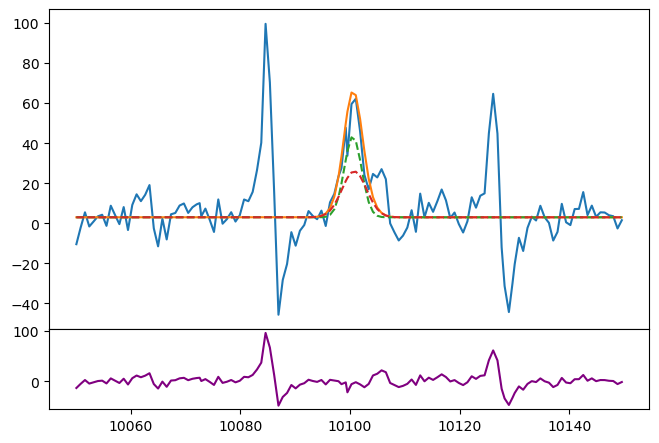

In [92]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9532.wavelength, siii_9532.flux)
bkg = 3

siiia_nar = gaussian(siii_9532.wavelength, 1.6e2, wave_cat['[SIII]9532'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, 1.3e2, wave_cat['[SIII]9532'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9532))

ax.plot(siii_9532.wavelength, bkg + siiia_nar + siiia_brd)
ax.plot(siii_9532.wavelength, bkg + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg + siiia_brd, ls='--')
ax1.plot(siii_9532.wavelength, siii_9532.flux - bkg - siiia_nar - siiia_brd, color='purple')
#ax.set_yscale('log')

In [93]:
params_siiia = Parameters()
params_siiia.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiia.add('z_ratio', value=z_ratio, vary=False)
params_siiia.add('sigma_nar', value=upy.nominal_values(sigma_nar_9532), vary=False)
params_siiia.add('sigma_brd', value=upy.nominal_values(sigma_brd_9532), vary=False)
params_siiia.add('Siiia_nar', value=0., vary=False)
params_siiia.add('Siiia_brd', value=1.3e2, min=0.)
params_siiia.add('bkg', value=3, min=0.)


def residual_siiia(params_siiia, x, data, uncertainty):
    
    z_nar = params_siiia['z_nar']
    z_brd = params_siiia['z_nar'] * params_siiia['z_ratio']
    sigma_nar = params_siiia['sigma_nar']
    sigma_brd = params_siiia['sigma_brd']
    siiia_nar_flux = params_siiia['Siiia_nar']
    siiia_brd_flux = params_siiia['Siiia_brd']
    bkg = params_siiia['bkg']
    
    x = siii_9532.wavelength
    model = gaussian(x, siiia_nar_flux, wave_cat['[SIII]9532'], z_nar, sigma_nar) + \
            gaussian(x, siiia_brd_flux, wave_cat['[SIII]9532'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9532.flux) / siii_9532.noise

In [94]:
np.random.seed(136)
out_siiia = minimize(residual_siiia, params_siiia, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 270.25it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [36.27231832 62.17403579 37.51653365]


In [95]:
out_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05974245,1.1690e-05,(0.02%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,1.57612491,,,1.57612490850496,-inf,inf,False
sigma_brd,2.25789259,,,2.2578925940501793,-inf,inf,False
Siiia_nar,0.00000000,,,0.0,-inf,inf,False
Siiia_brd,271.048993,10.8967183,(4.02%),130.0,0.00000000,inf,True
bkg,3.63864812,0.32136658,(8.83%),3,0.00000000,inf,True


In [96]:
np.random.seed(136)
out2_siiia = minimize(residual_siiia, out_siiia.params, args=(1, 1, 1),
                      method='leastsq')

In [97]:
out2_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05974211,3.8721e-05,(0.06%),0.059742449379861035,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,1.57612491,0.00000000,(0.00%),1.57612490850496,-inf,inf,False
sigma_brd,2.25789259,0.00000000,(0.00%),2.2578925940501793,-inf,inf,False
Siiia_nar,0.00000000,0.00000000,,0.0,-inf,inf,False
Siiia_brd,271.199440,35.0035012,(12.91%),271.04899269905866,0.00000000,inf,True
bkg,3.64183359,1.03878802,(28.52%),3.638648118010572,0.00000000,inf,True


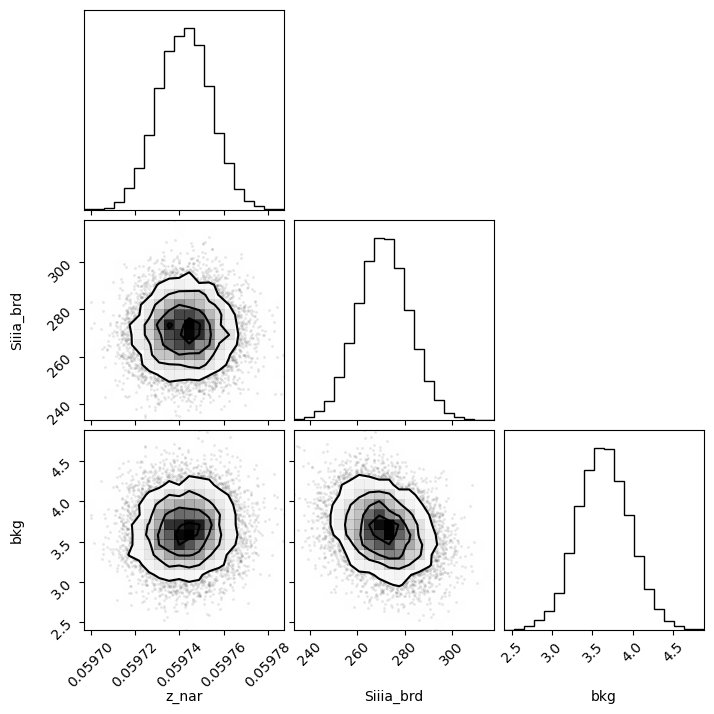

In [98]:
corner.corner(out_siiia.flatchain, labels=out_siiia.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_siiia.png')

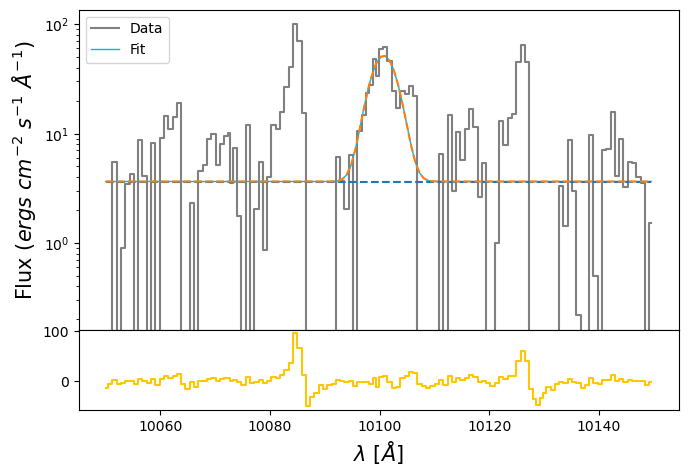

In [99]:
siiia_nar_flux = out2_siiia.params['Siiia_nar'].value
siiia_nar_std = out2_siiia.params['Siiia_nar'].stderr

siiia_brd_flux = out2_siiia.params['Siiia_brd'].value
siiia_brd_std = out2_siiia.params['Siiia_brd'].stderr

z_siiia = out2_siiia.params['z_nar'].value
z_siiia_std = out2_siiia.params['z_nar'].stderr

bkg_siiia = out2_siiia.params['bkg'].value
bkg_siiia_std = out2_siiia.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9532.wavelength, siii_9532.flux,
            color='gray', label='Data', where='mid')

siiia_nar = gaussian(siii_9532.wavelength, siiia_nar_flux, wave_cat['[SIII]9532'], z_siiia, upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, siiia_brd_flux, wave_cat['[SIII]9532'], z_siiia * z_ratio, upy.nominal_values(sigma_brd_9532))
siiia = siiia_nar + siiia_brd

ax.plot(siii_9532.wavelength, bkg_siiia + siiia, lw=1, color=c[0], label='Fit')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, bkg_siiia + siiia_brd, ls='--')
ax1.step(siii_9532.wavelength, siii_9532.flux - bkg_siiia - siiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [100]:
# EW
EW_SIII_9532_nar = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532_brd = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)
EW_SIII_9532 = (ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / ufloat(bkg_siiia, bkg_siiia_std)

# [SIII]9069

In [101]:
sigma_arc_9069 = (m * wave_cat['[SIII]9069']*(1 + z_BN[igal])) + n

sigma_nar_9069 = sigma_arc_9069
sigma_brd_9069 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9069**2))

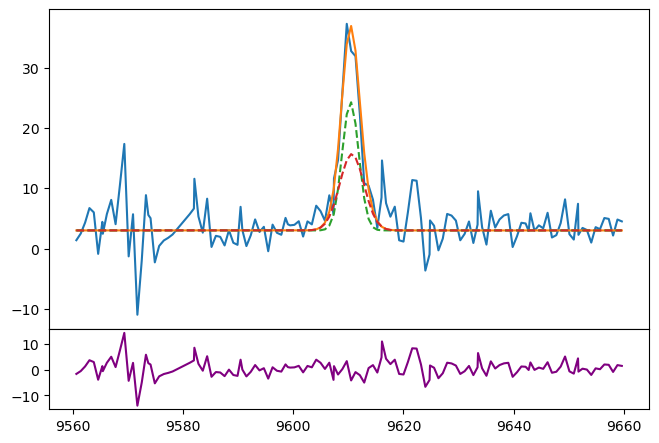

In [102]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9069.wavelength, siii_9069.flux)
bkg = 3

siiib_nar = gaussian(siii_9069.wavelength, 0.8e2, wave_cat['[SIII]9069'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, 0.7e2, wave_cat['[SIII]9069'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9069))

ax.plot(siii_9069.wavelength, bkg + siiib_nar + siiib_brd)
ax.plot(siii_9069.wavelength, bkg + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg + siiib_brd, ls='--')
ax1.plot(siii_9069.wavelength, siii_9069.flux - bkg - siiib_nar - siiib_brd, color='purple')
#ax.set_yscale('log')

In [103]:
params_siiib = Parameters()
params_siiib.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiib.add('z_ratio', value=z_ratio, vary=False)
params_siiib.add('sigma_nar', value=upy.nominal_values(sigma_nar_9069), vary=False)
params_siiib.add('sigma_brd', value=upy.nominal_values(sigma_brd_9069), vary=False)
params_siiib.add('Siiib_nar', value=0.8e2, min=0.)
params_siiib.add('Siiib_brd', value=0.7e2, min=0.)
params_siiib.add('bkg', value=3, min=0.)


def residual_siiib(params_siiib, x, data, uncertainty):
    
    z_nar = params_siiib['z_nar']
    z_brd = params_siiib['z_nar'] * params_siiib['z_ratio']
    sigma_nar = params_siiib['sigma_nar']
    sigma_brd = params_siiib['sigma_brd']
    siiib_nar_flux = params_siiib['Siiib_nar']
    siiib_brd_flux = params_siiib['Siiib_brd']
    bkg = params_siiib['bkg']
    
    x = siii_9069.wavelength
    model = gaussian(x, siiib_nar_flux, wave_cat['[SIII]9069'], z_nar, sigma_nar) + \
            gaussian(x, siiib_brd_flux, wave_cat['[SIII]9069'], z_brd, sigma_brd)
    
    return (model + bkg - siii_9069.flux) / siii_9069.noise

In [104]:
np.random.seed(136)
out_siiib = minimize(residual_siiib, params_siiib, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 273.50it/s]


In [105]:
out_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973340,1.1435e-05,(0.02%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,1.49739047,,,1.49739046546496,-inf,inf,False
sigma_brd,2.20365320,,,2.203653204368203,-inf,inf,False
Siiib_nar,79.2958332,17.8774144,(22.55%),80.0,0.00000000,inf,True
Siiib_brd,58.4611722,20.7304884,(35.46%),70.0,0.00000000,inf,True
bkg,3.59223738,0.17461563,(4.86%),3,0.00000000,inf,True


In [106]:
np.random.seed(136)
out2_siiib = minimize(residual_siiib, out_siiib.params, args=(1, 1, 1),
                      method='leastsq')

In [107]:
out2_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973387,1.5277e-05,(0.03%),0.05973340231977374,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,1.49739047,0.00000000,(0.00%),1.49739046546496,-inf,inf,False
sigma_brd,2.20365320,0.00000000,(0.00%),2.203653204368203,-inf,inf,False
Siiib_nar,80.2087676,24.4606150,(30.50%),79.29583318467039,0.00000000,inf,True
Siiib_brd,57.7973791,28.0421857,(48.52%),58.461172199986734,0.00000000,inf,True
bkg,3.59730021,0.23509601,(6.54%),3.592237382151734,0.00000000,inf,True


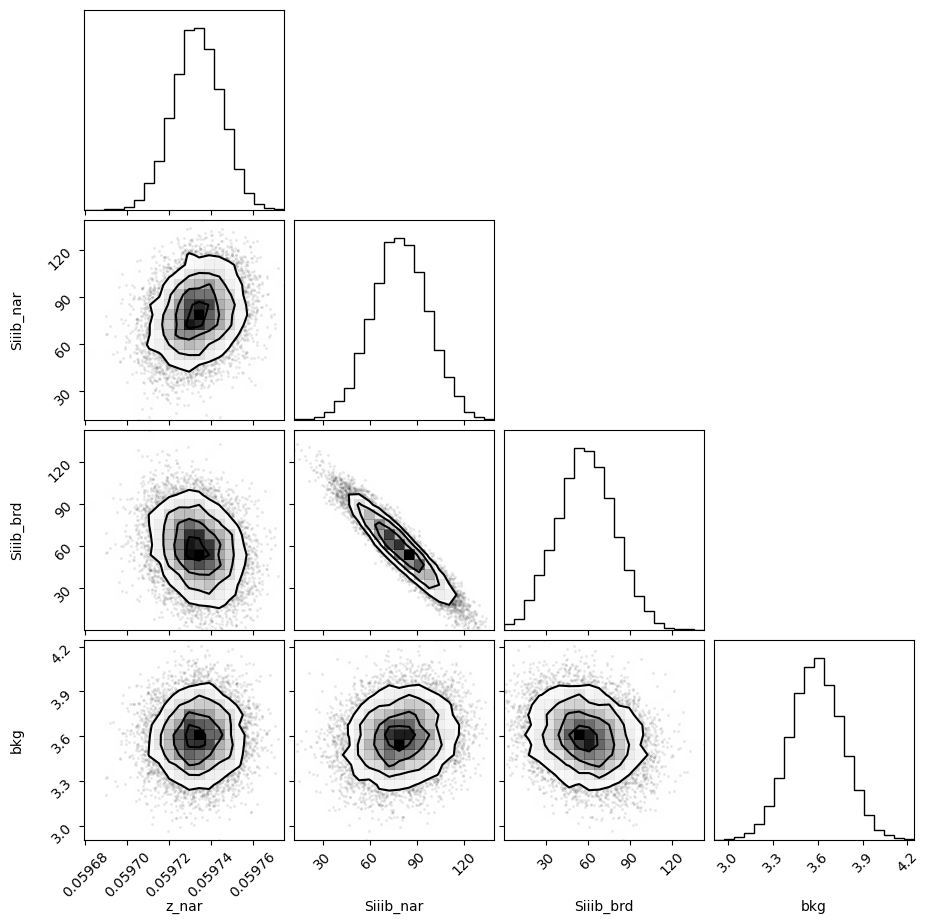

In [108]:
corner.corner(out_siiib.flatchain, labels=out_siiib.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_siiib.png')

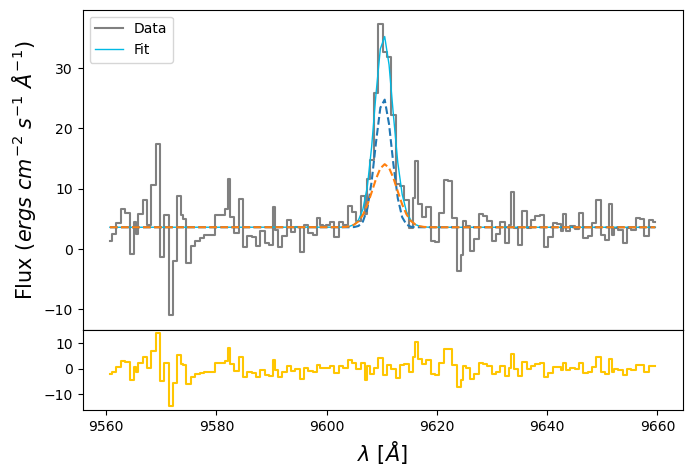

In [109]:
siiib_nar_flux = out2_siiib.params['Siiib_nar'].value
siiib_nar_std = out2_siiib.params['Siiib_nar'].stderr

siiib_brd_flux = out2_siiib.params['Siiib_brd'].value
siiib_brd_std = out2_siiib.params['Siiib_brd'].stderr

z_siiib = out2_siiib.params['z_nar'].value
z_siiib_std = out2_siiib.params['z_nar'].stderr

bkg_siiib = out2_siiib.params['bkg'].value
bkg_siiib_std = out2_siiib.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9069.wavelength, siii_9069.flux,
            color='gray', label='Data', where='mid')

siiib_nar = gaussian(siii_9069.wavelength, siiib_nar_flux, wave_cat['[SIII]9069'], z_siiib, upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, siiib_brd_flux, wave_cat['[SIII]9069'], z_siiib * z_ratio, upy.nominal_values(sigma_brd_9069))
siiib = siiib_nar + siiib_brd

ax.plot(siii_9069.wavelength, bkg_siiib + siiib, lw=1, color=c[0], label='Fit')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, bkg_siiib + siiib_brd, ls='--')
ax1.step(siii_9069.wavelength, siii_9069.flux - bkg_siiib - siiib, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

In [110]:
# EW
EW_SIII_9069_nar = ufloat(siiib_nar_flux, siiib_nar_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069_brd = ufloat(siiib_brd_flux, siiib_brd_std) / ufloat(bkg_siiib, bkg_siiib_std)
EW_SIII_9069 = (ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / ufloat(bkg_siiib, bkg_siiib_std)

# [OI]6300 + [SIII]6312

In [111]:
sigma_arc_6312 = (m * wave_cat['[SIII]6312']*(1 + z_BN[igal])) + n

sigma_nar_6312 = sigma_arc_6312
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

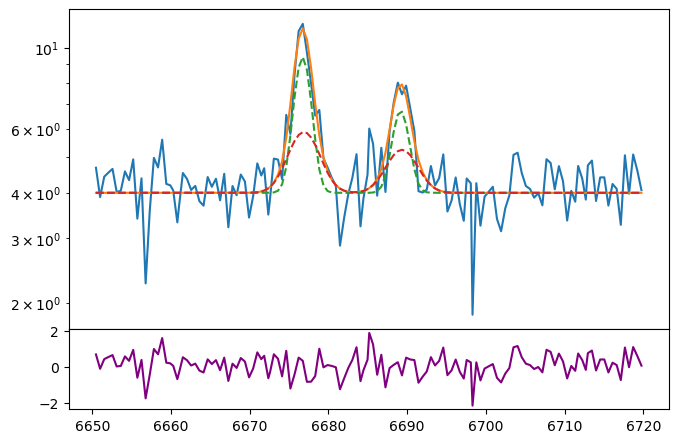

In [112]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 4.0

oi_nar = gaussian(oi_siii.wavelength, 1.4e1, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 0.9e1, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 0.7e1, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 0.6e1, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [113]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=1.4e1, min=0.)
params_oi_siii.add('Oi_brd', value=0.9e1, min=0.)
params_oi_siii.add('Siiic_nar', value=0.7e1, min=0.)
params_oi_siii.add('Siiic_brd', value=0., vary=False)
params_oi_siii.add('bkg', value=4.0, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [114]:
np.random.seed(136)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:13<00:00, 189.23it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [46.67596027 49.49290106 52.10442968 57.95745133 47.09229949]


In [115]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05974687,8.8713e-06,(0.01%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,1.02812638,,,1.028126375481216,-inf,inf,False
sigma_brd,1.91597314,,,1.9159731425615083,-inf,inf,False
Oi_nar,14.0217188,1.82926799,(13.05%),14.0,0.00000000,inf,True
Oi_brd,6.64953436,2.47068455,(37.16%),9.0,0.00000000,inf,True
Siiic_nar,10.6150717,0.77203784,(7.27%),7.0,0.00000000,inf,True
Siiic_brd,0.00000000,,,0.0,-inf,inf,False
bkg,4.16416230,0.04722890,(1.13%),4.0,0.00000000,inf,True


In [116]:
np.random.seed(136)
out2_oi_siii = minimize(residual_oi_siii, out_oi_siii.params, args=(1, 1, 1),
                      method='leastsq')

In [117]:
out2_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05974722,1.0780e-05,(0.02%),0.05974687092584318,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,1.02812638,0.00000000,(0.00%),1.028126375481216,-inf,inf,False
sigma_brd,1.91597314,0.00000000,(0.00%),1.9159731425615083,-inf,inf,False
Oi_nar,14.1434272,2.22141848,(15.71%),14.021718832500433,0.00000000,inf,True
Oi_brd,6.60047617,2.98690824,(45.25%),6.649534360535976,0.00000000,inf,True
Siiic_nar,10.6211173,0.91275783,(8.59%),10.61507172987276,0.00000000,inf,True
Siiic_brd,0.00000000,0.00000000,,0.0,-inf,inf,False
bkg,4.16201146,0.05580718,(1.34%),4.164162296849385,0.00000000,inf,True


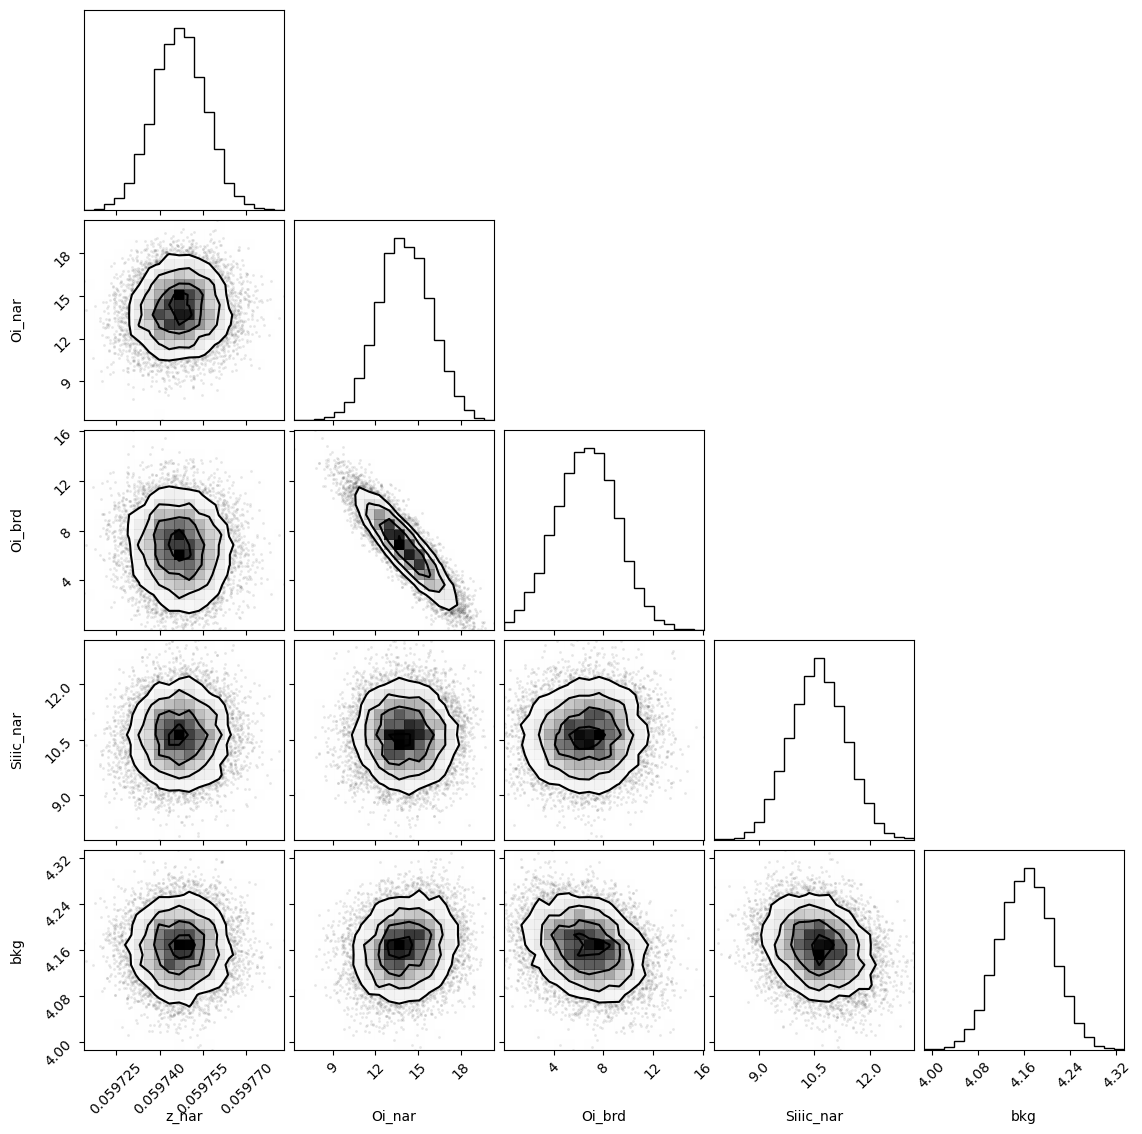

In [118]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_oi_siiic.png')

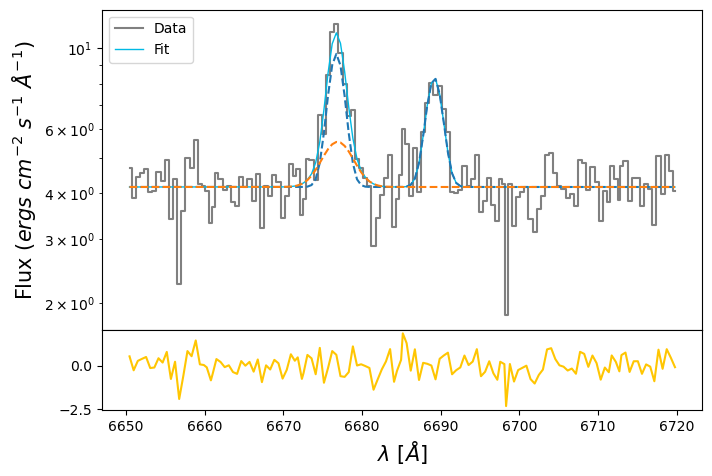

In [119]:
oia_nar_flux = out2_oi_siii.params['Oi_nar'].value
oia_nar_std = out2_oi_siii.params['Oi_nar'].stderr

oia_brd_flux = out2_oi_siii.params['Oi_brd'].value
oia_brd_std = out2_oi_siii.params['Oi_brd'].stderr

siiic_nar_flux = out2_oi_siii.params['Siiic_nar'].value
siiic_nar_std = out2_oi_siii.params['Siiic_nar'].stderr

siiic_brd_flux = out2_oi_siii.params['Siiic_brd'].value
siiic_brd_std = out2_oi_siii.params['Siiic_brd'].stderr

z_oi_siii = out2_oi_siii.params['z_nar'].value
z_oi_siii_std = out2_oi_siii.params['z_nar'].stderr

bkg_oi_siii = out2_oi_siii.params['bkg'].value
bkg_oi_siii_std = out2_oi_siii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oia_nar = gaussian(oi_siii.wavelength, oia_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oia_brd = gaussian(oi_siii.wavelength, oia_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oia = oia_nar + oia_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oia,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oia_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oia_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [120]:
# EW
EW_OI_6300_nar = ufloat(oia_nar_flux, oia_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oia_brd_flux, oia_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

# [OIII]5007 + HeI 5015

In [121]:
sigma_arc_5007 = (m * wave_cat['[OIII]5007']*(1 + z_BN[igal])) + n

sigma_nar_5007 = sigma_arc_5007
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

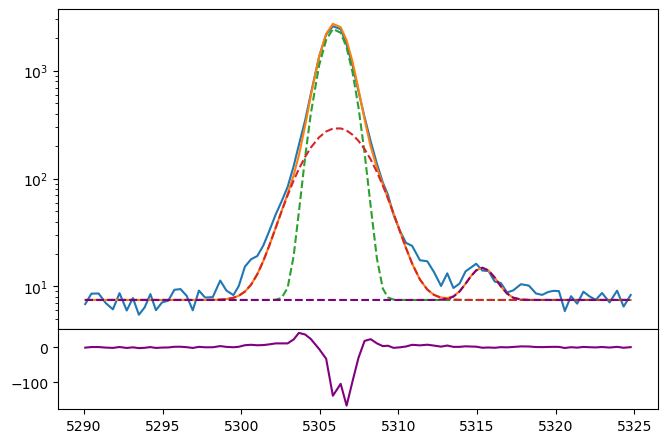

In [122]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 7.5

oiiia_nar = gaussian(oiii_hei.wavelength, 5e3, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, 1.3e3, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5007))

hei_5015 = gaussian(oiii_hei.wavelength, 1.5e1, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [123]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=upy.nominal_values(sigma_nar_5007), vary=False)
params_oiii_hei.add('sigma_brd', value=upy.nominal_values(sigma_brd_5007), vary=False)
params_oiii_hei.add('Hei', value=1.5e1, min=0.)
params_oiii_hei.add('Oiiia_nar', value=5.0e3, min=0.)
params_oiii_hei.add('Oiiia_brd', value=1.3e3, min=0.)
params_oiii_hei.add('bkg', value=7.5, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [124]:
np.random.seed(136)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:11<00:00, 214.32it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [39.95658902 49.41091668 60.45525562 58.65289821 42.47368538]


In [125]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973747,3.4662e-07,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.80593063,,,0.8059306272837248,-inf,inf,False
sigma_brd,1.80649755,,,1.8064975546761244,-inf,inf,False
Hei,13.9717722,1.21039013,(8.66%),15.0,0.00000000,inf,True
Oiiia_nar,4607.83694,12.9649979,(0.28%),5000.0,0.00000000,inf,True
Oiiia_brd,1528.36696,11.7451610,(0.77%),1300.0,0.00000000,inf,True
bkg,8.59963594,0.12938243,(1.50%),7.5,0.00000000,inf,True


In [126]:
np.random.seed(136)
out2_oiii_hei = minimize(residual_oiii_hei, out_oiii_hei.params, args=(1, 1, 1),
                      method='leastsq')

In [127]:
out2_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973748,7.8911e-07,(0.00%),0.05973746649772735,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.80593063,0.00000000,(0.00%),0.8059306272837248,-inf,inf,False
sigma_brd,1.80649755,0.00000000,(0.00%),1.8064975546761244,-inf,inf,False
Hei,13.9916112,2.75357283,(19.68%),13.971772186529742,0.00000000,inf,True
Oiiia_nar,4607.91496,28.5383076,(0.62%),4607.836935168644,0.00000000,inf,True
Oiiia_brd,1528.58492,25.9487214,(1.70%),1528.36696228551,0.00000000,inf,True
bkg,8.60047972,0.29581072,(3.44%),8.599635942299052,0.00000000,inf,True


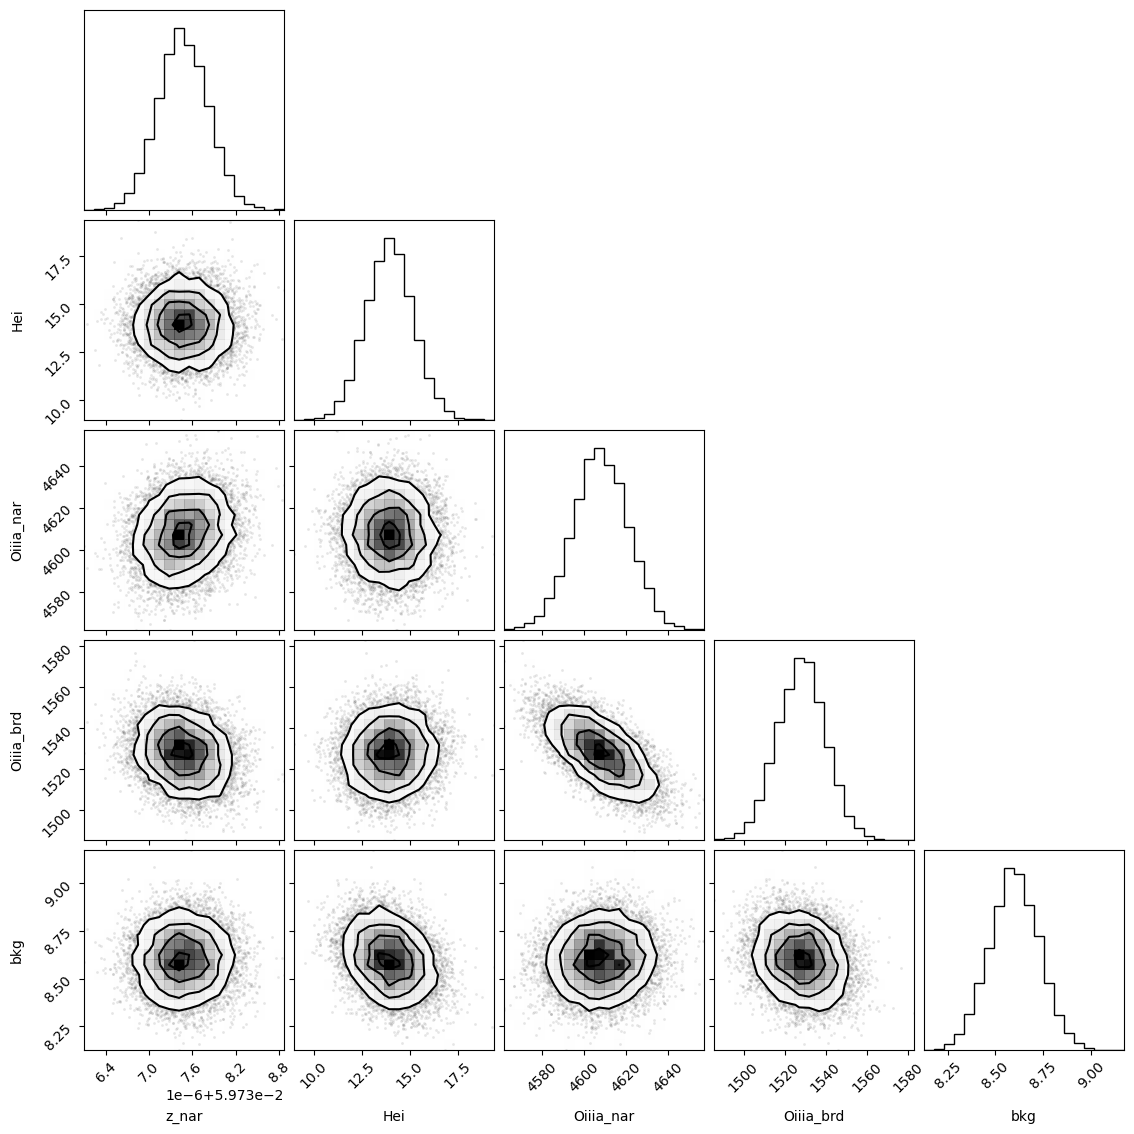

In [128]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_oiiia.png')

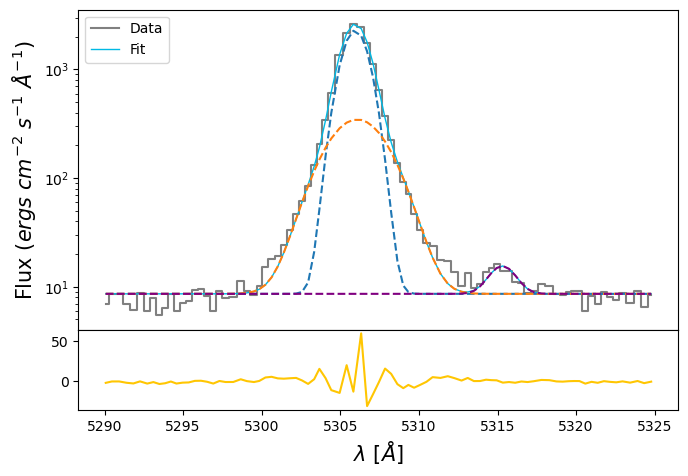

In [129]:
hei_flux = out2_oiii_hei.params['Hei'].value
hei_std = out2_oiii_hei.params['Hei'].stderr

oiiia_nar_flux = out2_oiii_hei.params['Oiiia_nar'].value
oiiia_nar_std = out2_oiii_hei.params['Oiiia_nar'].stderr

oiiia_brd_flux = out2_oiii_hei.params['Oiiia_brd'].value
oiiia_brd_std = out2_oiii_hei.params['Oiiia_brd'].stderr

z_oiii_hei = out2_oiii_hei.params['z_nar'].value
z_oiii_hei_std = out2_oiii_hei.params['z_nar'].stderr

bkg_oiii_hei = out2_oiii_hei.params['bkg'].value
bkg_oiii_hei_std = out2_oiii_hei.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [130]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

# [OIII]4363

In [131]:
sigma_arc_4363 = (m * wave_cat['[OIII]4363']*(1 + z_BN[igal])) + n

sigma_nar_4363 = sigma_arc_4363
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

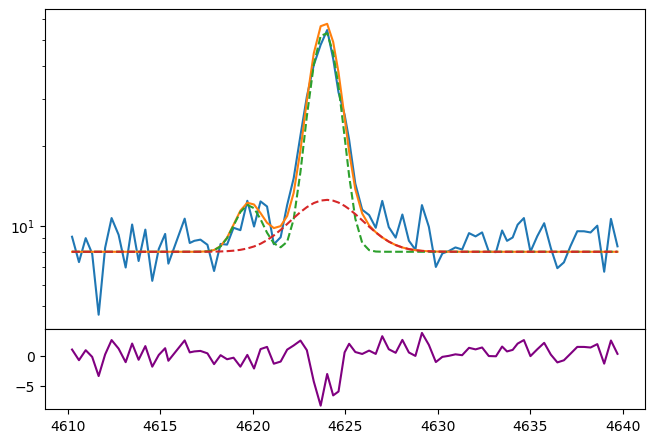

In [132]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 8

feii_4360 = gaussian(oiii_4363.wavelength, 0.7e1, wave_cat['[FeII]4360'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, 8e1, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 2e1, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd + feii_4360)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd - feii_4360, color='purple')
ax.set_yscale('log')

In [133]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Feii_4360_nar', value=0.7e1, min=0.)
params_oiiic.add('Oiiic_nar', value=8e1, min=0.)
params_oiiic.add('Oiiic_brd', value=2e1, min=0.)
params_oiiic.add('bkg', value=8, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    feii_4360_flux = params_oiiic['Feii_4360_nar']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, feii_4360_flux, wave_cat['[FeII]4360'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [134]:
np.random.seed(136)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:10<00:00, 228.80it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [50.59283576 54.20568444 64.41464581 53.39514969 48.7935788 ]


In [135]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973653,5.6049e-06,(0.01%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.69636054,,,0.6963605418532224,-inf,inf,False
sigma_brd,1.76034861,,,1.7603486141406743,-inf,inf,False
Feii_4360_nar,3.73692046,1.43175543,(38.31%),7.0,0.00000000,inf,True
Oiiic_nar,63.7295063,3.03182232,(4.76%),80.0,0.00000000,inf,True
Oiiic_brd,28.6213567,4.59060981,(16.04%),20.0,0.00000000,inf,True
bkg,8.61013301,0.18485023,(2.15%),8,0.00000000,inf,True


In [136]:
np.random.seed(136)
out2_oiiic = minimize(residual_oiiic, out_oiiic.params, args=(1, 1, 1),
                      method='leastsq')

In [137]:
out2_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973675,5.2209e-06,(0.01%),0.059736533079691276,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.69636054,0.00000000,(0.00%),0.6963605418532224,-inf,inf,False
sigma_brd,1.76034861,0.00000000,(0.00%),1.7603486141406743,-inf,inf,False
Feii_4360_nar,3.82678918,1.34527364,(35.15%),3.736920458844312,0.00000000,inf,True
Oiiic_nar,64.0063537,2.78126358,(4.35%),63.72950626533377,0.00000000,inf,True
Oiiic_brd,28.3757936,4.29043752,(15.12%),28.62135667211063,0.00000000,inf,True
bkg,8.60976058,0.17808893,(2.07%),8.610133007242041,0.00000000,inf,True


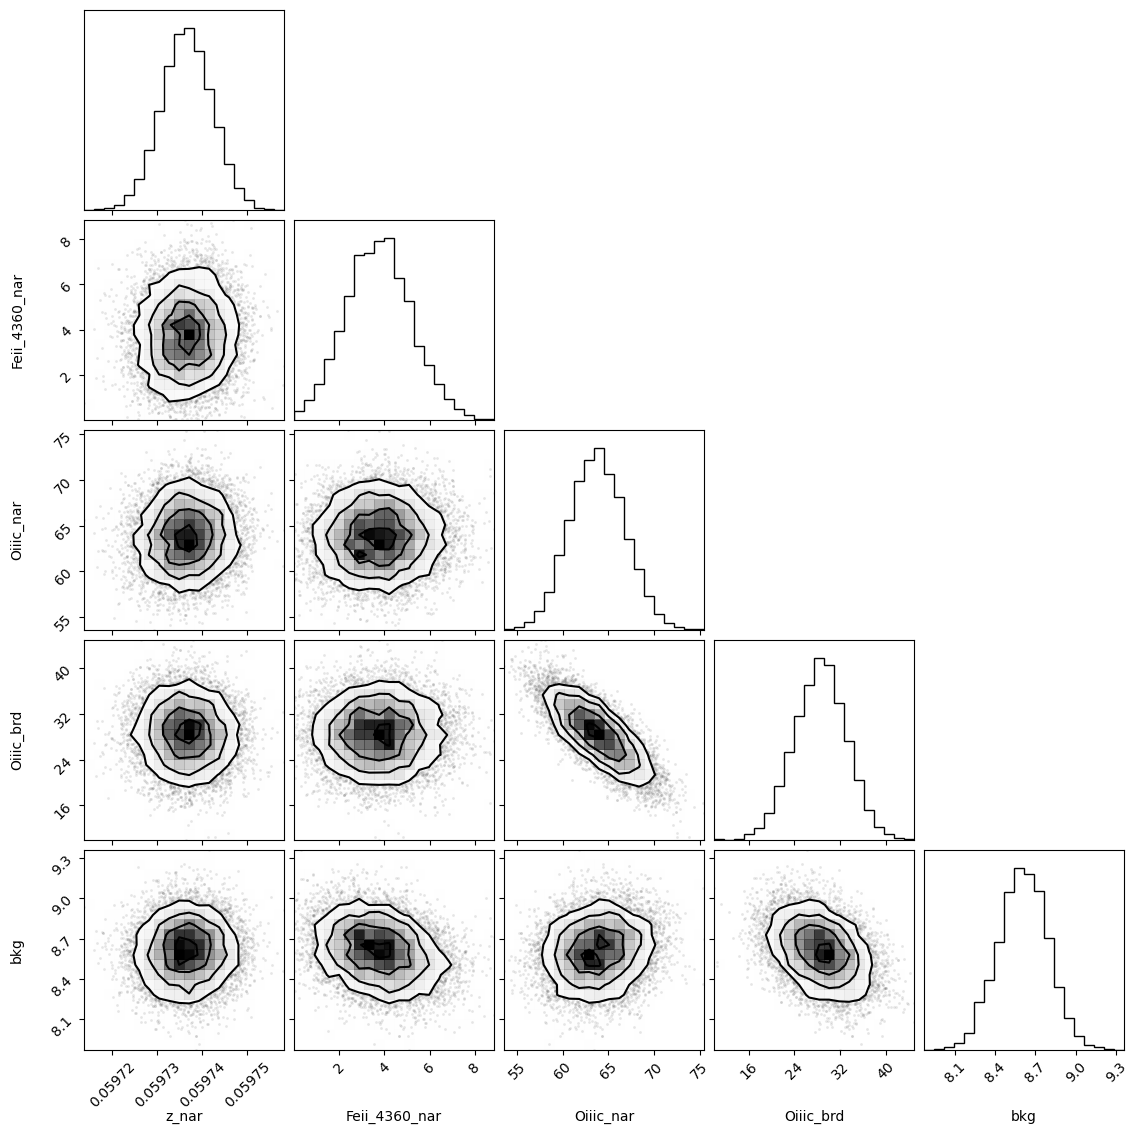

In [138]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig('/home/benjamin/Desktop/corner_oiiic.png')

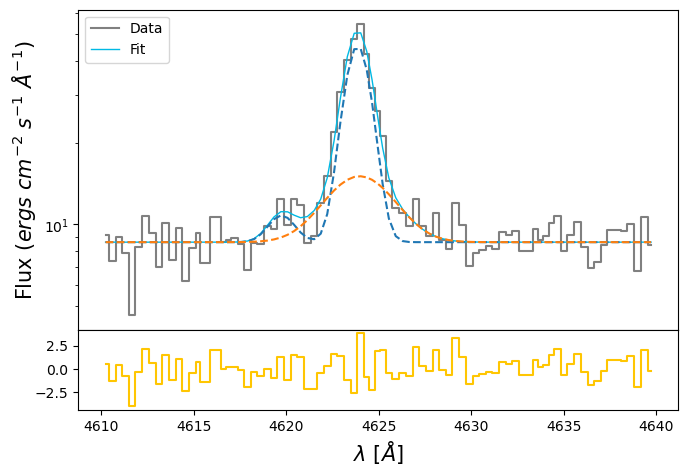

In [139]:
oiiic_nar_flux = out2_oiiic.params['Oiiic_nar'].value
oiiic_nar_std = out2_oiiic.params['Oiiic_nar'].stderr

oiiic_brd_flux = out2_oiiic.params['Oiiic_brd'].value
oiiic_brd_std = out2_oiiic.params['Oiiic_brd'].stderr

feii_4360_flux = out2_oiiic.params['Feii_4360_nar'].value
feii_4360_std = out2_oiiic.params['Feii_4360_nar'].stderr

z_oiii = out2_oiiic.params['z_nar'].value
z_oiii_std = out2_oiiic.params['z_nar'].stderr

bkg_oiiic = out2_oiiic.params['bkg'].value
bkg_oiiic_std = out2_oiiic.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

feii_4360 = gaussian(oiii_4363.wavelength, feii_4360_flux, wave_cat['[FeII]4360'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic + feii_4360, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic - feii_4360, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [140]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

# [ArIII]7135

In [141]:
sigma_arc_7135 = (m * wave_cat['[ArIII]7135']*(1 + z_BN[igal])) + n

sigma_nar_7135 = sigma_arc_7135
sigma_brd_7135 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7135**2))

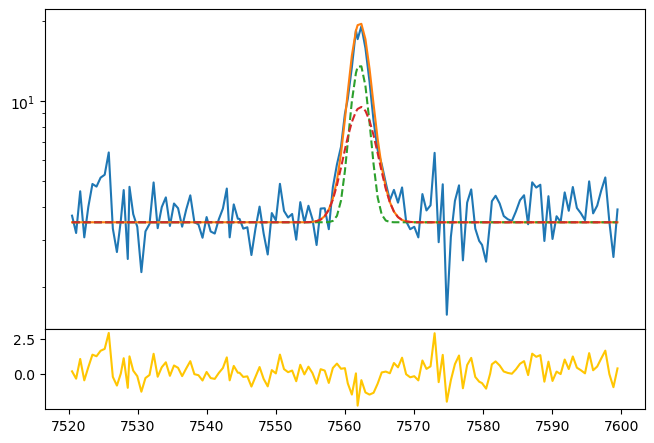

In [142]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariii_7135.wavelength, ariii_7135.flux)
bkg = 3.5

ariiia_nar = gaussian(ariii_7135.wavelength, 3e1, wave_cat['[ArIII]7135'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, 3e1, wave_cat['[ArIII]7135'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7135))

ax.plot(ariii_7135.wavelength, bkg + ariiia_nar + ariiia_brd)
ax.plot(ariii_7135.wavelength, bkg + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg + ariiia_brd, ls='--')
ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg - ariiia_nar - ariiia_brd, color=c[3])
ax.set_yscale('log')

In [143]:
params_ariii = Parameters()
params_ariii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariii.add('z_ratio', value=z_ratio, vary=False)
params_ariii.add('sigma_nar', value=upy.nominal_values(sigma_nar_7135), vary=False)
params_ariii.add('sigma_brd', value=upy.nominal_values(sigma_brd_7135), vary=False)
params_ariii.add('Ariiia_nar', value=3e1, min=0.)
params_ariii.add('Ariiia_brd', value=3e1, min=0.)
params_ariii.add('bkg', value=3.5, min=0.)


def residual_ariii(params_ariii, x, data, uncertainty):
    
    z_nar = params_ariii['z_nar']
    z_brd = params_ariii['z_nar'] * params_ariii['z_ratio']
    sigma_nar = params_ariii['sigma_nar']
    sigma_brd = params_ariii['sigma_brd']
    ariiia_nar = params_ariii['Ariiia_nar']
    ariiia_brd = params_ariii['Ariiia_brd']
    bkg = params_ariii['bkg']
    
    x = ariii_7135.wavelength
    model_ariii = gaussian(x, ariiia_nar, wave_cat['[ArIII]7135'], z_nar, sigma_nar) \
                + gaussian(x, ariiia_brd, wave_cat['[ArIII]7135'], z_brd, sigma_brd)
    
    return (model_ariii + bkg - ariii_7135.flux) / ariii_7135.noise

In [144]:
np.random.seed(136)
out_ariii = minimize(residual_ariii, params_ariii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 259.64it/s]


In [145]:
out_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973607,6.0129e-06,(0.01%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,1.16835710,,,1.16835710004288,-inf,inf,False
sigma_brd,1.99473496,,,1.9947349579022993,-inf,inf,False
Ariiia_nar,29.8818047,2.69063692,(9.00%),30.0,0.00000000,inf,True
Ariiia_brd,23.7195124,3.40289903,(14.35%),30.0,0.00000000,inf,True
bkg,3.75546625,0.04888977,(1.30%),3.5,0.00000000,inf,True


In [146]:
np.random.seed(136)
out2_ariii = minimize(residual_ariii, out_ariii.params, args=(1, 1, 1), method='leastsq')

In [147]:
out2_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05973620,7.3714e-06,(0.01%),0.059736067960279804,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,1.16835710,0.00000000,(0.00%),1.16835710004288,-inf,inf,False
sigma_brd,1.99473496,0.00000000,(0.00%),1.9947349579022993,-inf,inf,False
Ariiia_nar,29.8012675,3.27123656,(10.98%),29.88180465333031,0.00000000,inf,True
Ariiia_brd,23.7584481,4.16645586,(17.54%),23.719512380434125,0.00000000,inf,True
bkg,3.75473449,0.05925299,(1.58%),3.7554662533982026,0.00000000,inf,True


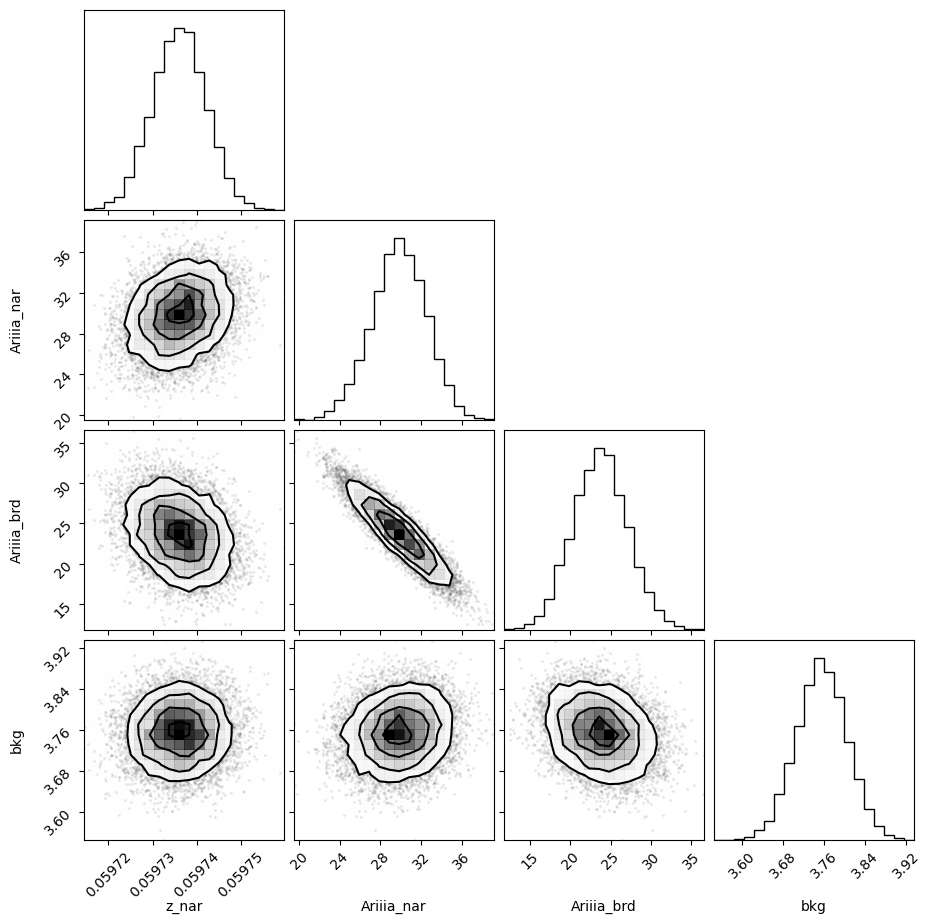

In [148]:
corner.corner(out_ariii.flatchain, labels=out_ariii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

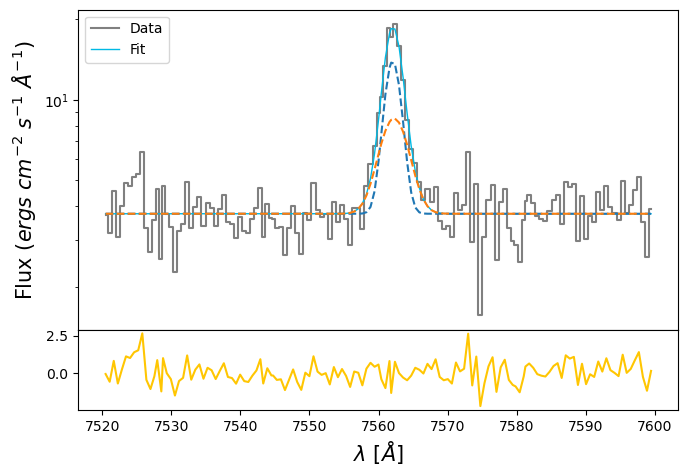

In [149]:
ariiia_nar_flux = out2_ariii.params['Ariiia_nar'].value
ariiia_nar_std = out2_ariii.params['Ariiia_nar'].stderr

ariiia_brd_flux = out2_ariii.params['Ariiia_brd'].value
ariiia_brd_std = out2_ariii.params['Ariiia_brd'].stderr

z_ariii = out2_ariii.params['z_nar'].value
z_ariii_std = out2_ariii.params['z_nar'].stderr

bkg_ariii = out2_ariii.params['bkg'].value
bkg_ariii_std = out2_ariii.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariii_7135.wavelength, ariii_7135.flux,
            color='gray', label='Data', where='mid')

ariiia_nar = gaussian(ariii_7135.wavelength, ariiia_nar_flux, wave_cat['[ArIII]7135'], z_ariii, upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, ariiia_brd_flux, wave_cat['[ArIII]7135'], z_ariii * z_ratio, upy.nominal_values(sigma_brd_7135))

ariiia = ariiia_nar + ariiia_brd

ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia,
        lw=1, color=c[0], label='Fit')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_brd, ls='--')

ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg_ariii - ariiia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [150]:
# EW
EW_ArIII_7135_nar = ufloat(ariiia_nar_flux, ariiia_nar_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135_brd = ufloat(ariiia_brd_flux, ariiia_brd_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135 = (ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / ufloat(bkg_ariii, bkg_ariii_std)

# [NeIII]3868

In [151]:
sigma_arc_3868 = (m * wave_cat['[NeIII]3868']*(1 + z_BN[igal])) + n

sigma_nar_3868 = sigma_arc_3868
sigma_brd_3868 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3868**2))

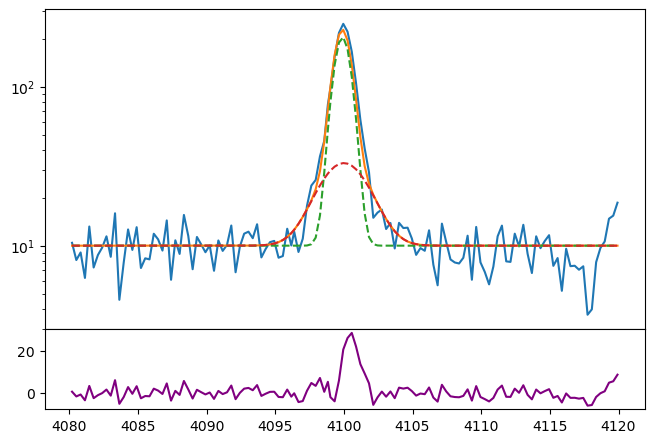

In [152]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(neiii_3868.wavelength, neiii_3868.flux)
bkg = 1e1

neiiia_nar = gaussian(neiii_3868.wavelength, 3e2, wave_cat['[NeIII]3868'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, 1e2, wave_cat['[NeIII]3868'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3868))

ax.plot(neiii_3868.wavelength, bkg + neiiia_nar + neiiia_brd)
ax.plot(neiii_3868.wavelength, bkg + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg + neiiia_brd, ls='--')
ax1.plot(neiii_3868.wavelength, neiii_3868.flux - bkg - neiiia_nar - neiiia_brd, color='purple')
ax.set_yscale('log')

In [153]:
params_neiii_3868 = Parameters()
params_neiii_3868.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_neiii_3868.add('z_ratio', value=z_ratio, vary=False)
params_neiii_3868.add('sigma_nar', value=upy.nominal_values(sigma_nar_3868), vary=False)
params_neiii_3868.add('sigma_brd', value=upy.nominal_values(sigma_brd_3868), vary=False)
params_neiii_3868.add('Neiiia_nar', value=3e2, min=0.)
params_neiii_3868.add('Neiiia_brd', value=1e2, min=0.)
params_neiii_3868.add('bkg', value=1e1, min=0.)


def residual_neiii_3868(params_neiii_3868, x, data, uncertainty):
    
    z_nar = params_neiii_3868['z_nar']
    z_brd = params_neiii_3868['z_nar'] * params_neiii_3868['z_ratio']
    sigma_nar = params_neiii_3868['sigma_nar']
    sigma_brd = params_neiii_3868['sigma_brd']
    neiiia_nar_flux = params_neiii_3868['Neiiia_nar']
    neiiia_brd_flux = params_neiii_3868['Neiiia_brd']
    bkg = params_neiii_3868['bkg']
    
    x = neiii_3868.wavelength
    model = gaussian(x, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_nar, sigma_nar) + \
            gaussian(x, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_brd, sigma_brd)
    
    return (model + bkg - neiii_3868.flux) / neiii_3868.noise

In [154]:
np.random.seed(136)
out_neiii_3868 = minimize(residual_neiii_3868, params_neiii_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████| 2500/2500 [00:09<00:00, 264.68it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [35.59350976 41.00374941 60.9626496  46.55025395]


In [155]:
out_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05976217,2.0255e-06,(0.00%),0.05974383322628328,-inf,inf,True
z_ratio,1.00044051,,,1.0004405107310728,-inf,inf,False
sigma_nar,0.61218721,,,0.612187208606336,-inf,inf,False
sigma_brd,1.72878062,,,1.7287806157630576,-inf,inf,False
Neiiia_nar,322.365063,4.80526590,(1.49%),300.0,0.00000000,inf,True
Neiiia_brd,123.568622,6.50834610,(5.27%),100.0,0.00000000,inf,True
bkg,9.50757630,0.21419426,(2.25%),10.0,0.00000000,inf,True


In [156]:
np.random.seed(136)
out2_neiii_3868 = minimize(residual_neiii_3868, out_neiii_3868.params, args=(1, 1, 1), method='leastsq')

In [157]:
out2_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.05976220,2.5470e-06,(0.00%),0.05976217046854579,-inf,inf,True
z_ratio,1.00044051,0.00000000,(0.00%),1.0004405107310728,-inf,inf,False
sigma_nar,0.61218721,0.00000000,(0.00%),0.612187208606336,-inf,inf,False
sigma_brd,1.72878062,0.00000000,(0.00%),1.7287806157630576,-inf,inf,False
Neiiia_nar,322.385452,5.98046452,(1.86%),322.3650634011037,0.00000000,inf,True
Neiiia_brd,123.585775,8.21655152,(6.65%),123.56862223550182,0.00000000,inf,True
bkg,9.50752596,0.27312616,(2.87%),9.507576296660694,0.00000000,inf,True


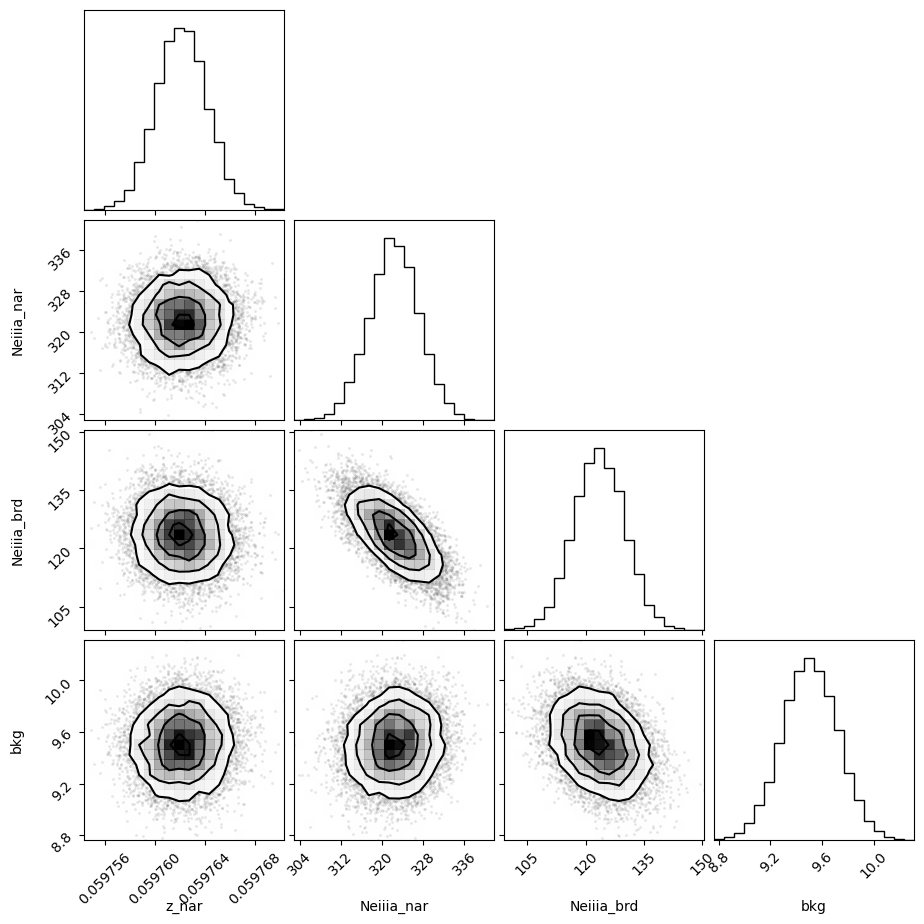

In [158]:
corner.corner(out_neiii_3868.flatchain, labels=out_neiii_3868.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

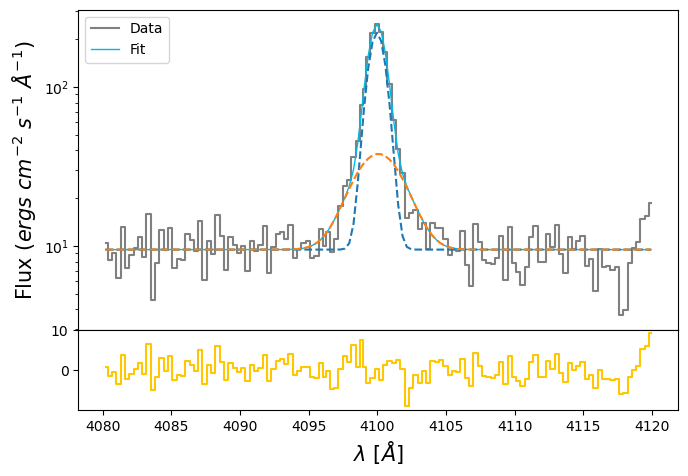

In [159]:
neiiia_nar_flux = out2_neiii_3868.params['Neiiia_nar'].value
neiiia_nar_std = out2_neiii_3868.params['Neiiia_nar'].stderr

neiiia_brd_flux = out2_neiii_3868.params['Neiiia_brd'].value
neiiia_brd_std = out2_neiii_3868.params['Neiiia_brd'].stderr

z_neiii = out2_neiii_3868.params['z_nar'].value
z_neiii_std = out2_neiii_3868.params['z_nar'].stderr

bkg_neiiia = out2_neiii_3868.params['bkg'].value
bkg_neiiia_std = out2_neiii_3868.params['bkg'].stderr

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(neiii_3868.wavelength, neiii_3868.flux,
            color='gray', label='Data', where='mid')

neiiia_nar = gaussian(neiii_3868.wavelength, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_neiii, upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_neiii * z_ratio, upy.nominal_values(sigma_brd_3868))
neiiia = neiiia_nar + neiiia_brd

ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia, lw=1, color=c[0], label='Fit')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_brd, ls='--')
ax1.step(neiii_3868.wavelength, neiii_3868.flux - bkg_neiiia - neiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [160]:
# EW
EW_NeIII_3868_nar = ufloat(neiiia_nar_flux, neiiia_nar_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868_brd = ufloat(neiiia_brd_flux, neiiia_brd_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868 = (ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / ufloat(bkg_neiiia, bkg_neiiia_std)

# ----------------------------------------

# Balmer decrements

In [161]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

flux_ha_bal = ufloat(np.mean(out_ha_nii.flatchain.Ha_nar + out_ha_nii.flatchain.Ha_brd), 
                      np.std(out_ha_nii.flatchain.Ha_nar + out_ha_nii.flatchain.Ha_brd))

flux_hb_bal = ufloat(np.mean(out_hb.flatchain.Hb_nar + out_hb.flatchain.Hb_brd), 
                      np.std(out_hb.flatchain.Hb_nar + out_hb.flatchain.Hb_brd))

flux_hg_bal = ufloat(np.mean(out_hg.flatchain.Hg_nar + out_hg.flatchain.Hg_brd), 
                      np.std(out_hg.flatchain.Hg_nar + out_hg.flatchain.Hg_brd))

flux_hd_bal = ufloat(np.mean(out_hd.flatchain.Hd_nar + out_hd.flatchain.Hd_brd), 
                      np.std(out_hd.flatchain.Hd_nar + out_hd.flatchain.Hd_brd))

y_balmer = upy.log10([(flux_ha_bal / flux_hb_bal) / 2.86, 
                    (flux_hb_bal / flux_hb_bal) / 1.0,
                    (flux_hg_bal / flux_hb_bal) / 0.464,
                    (flux_hd_bal / flux_hb_bal) / 0.256])

x_balmer = np.array([k_cal(wave_cat['Ha']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hb']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hg']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hd']) - k_cal(wave_cat['Hb'])])

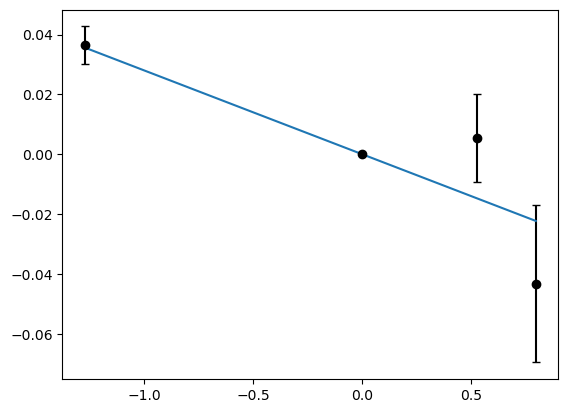

In [162]:
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), 3*upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, x_balmer * (-0.4 * 0.07))

In [163]:
mask_balmer = (y_balmer != 0)

params_balmer = Parameters()
params_balmer.add('slope', value=0.4 * 0.07)

def residuals_balmer(params_balmer, x, data, uncertainty):
    
    slope = params_balmer['slope']
    x = x_balmer[mask_balmer]
    
    model = x * (-slope)
    return (model - upy.nominal_values(y_balmer[mask_balmer])) / upy.std_devs(y_balmer[mask_balmer])

np.random.seed(136)
out_balmer = minimize(residuals_balmer, params_balmer, args=(1, 1, 1),
                      method='leastsq')

In [164]:
out_balmer.params

name,value,standard error,relative error,initial value,min,max,vary
slope,0.02802627,0.00538508,(19.21%),0.028000000000000004,-inf,inf,True


In [175]:
color_excess = ufloat(out_balmer.params['slope'].value, out_balmer.params['slope'].stderr) / 0.4
E_BV = out_balmer.params['slope'].value / 0.4

texPlot('on')
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), 3*upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, - E_BV * 0.4 * x_balmer, ls='--', color='red')
plt.ylabel(r'log(R$_{obs}$/R$_{int}$)')
plt.xlabel(r'$k(\lambda) - k($H$\beta)$')
plt.title(r'J0136-0037; $E(B-V) = $ '+str(round(color_excess.nominal_value, 3))+' $\pm$ '+str(round(color_excess.std_dev, 3)))
# plt.savefig('/home/benjamin/Documents/analogs/results/balmer_decrements/bal_dec_chains_J0136.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'J0136-0037; $E(B-V) = $ 0.07 $\\pm$ 0.013')

Error in callback <function _draw_all_if_interactive at 0x10ec10720> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 1 Axes>

In [176]:
decrement_dict = {'galname': galname,
                 'Ha/Hb': (flux_ha_bal / flux_hb_bal).nominal_value,
                 'Ha/Hb_err': (flux_ha_bal / flux_hb_bal).std_dev,
                 'Hg/Hb': (flux_hg_bal / flux_hb_bal).nominal_value,
                 'Hg/Hb_err': (flux_hg_bal / flux_hb_bal).std_dev,
                 'Hd/Hb': (flux_hd_bal / flux_hb_bal).nominal_value,
                 'Hd/Hb_err': (flux_hd_bal / flux_hb_bal).std_dev,
                 'E_BV': out_balmer.params['slope'].value / 0.4,
                 'E_BV_err': out_balmer.params['slope'].stderr / 0.4
                 }
decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
save_catalog(galname, decrement_dict_pd, DIR + '/results/bal_decrements_chains.csv')

Existent catalog (.csv) file.
Non existent data for J0136, adding new data...
Done.


# Dust correction

In [177]:
oiid_nar_chain = out_oii_3727.flatchain.Oiid_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_brd_chain = out_oii_3727.flatchain.Oiid_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_tot_chain = oiid_nar_chain + oiid_brd_chain

oiic_nar_chain = out_oii_3727.flatchain.Oiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_brd_chain = out_oii_3727.flatchain.Oiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_tot_chain = oiic_nar_chain + oiic_brd_chain

neiiia_nar_chain = out_neiii_3868.flatchain.Neiiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[NeIII]3868']))
neiiia_brd_chain = out_neiii_3868.flatchain.Neiiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[NeIII]3868']))
neiiia_tot_chain = neiiia_nar_chain + neiiia_brd_chain

hd_nar_chain = out_hd.flatchain.Hd_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Hd']))
hd_brd_chain = out_hd.flatchain.Hd_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Hd']))
hd_tot_chain = hd_nar_chain + hd_brd_chain

hg_nar_chain = out_hg.flatchain.Hg_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Hg']))
hg_brd_chain = out_hg.flatchain.Hg_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Hg']))
hg_tot_chain = hg_nar_chain + hg_brd_chain

oiiic_nar_chain = out_oiiic.flatchain.Oiiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_brd_chain = out_oiiic.flatchain.Oiiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_tot_chain = oiiic_nar_chain + oiiic_brd_chain

heid_nar_chain = np.nan * np.ones(10000)
heid_brd_chain = np.nan * np.ones(10000)
heid_tot_chain = np.nan * np.ones(10000)

feiiia_nar_chain = np.nan * np.ones(10000)
feiiia_brd_chain = np.nan * np.ones(10000)
feiiia_tot_chain = np.nan * np.ones(10000)

heiia_nar_chain = np.nan * np.ones(10000)
heiia_brd_chain = np.nan * np.ones(10000)
heiia_tot_chain = np.nan * np.ones(10000)

ariva_nar_chain = np.nan * np.ones(10000)
ariva_brd_chain = np.nan * np.ones(10000)
ariva_tot_chain = np.nan * np.ones(10000)

hb_nar_chain = out_hb.flatchain.Hb_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_brd_chain = out_hb.flatchain.Hb_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_tot_chain = hb_nar_chain + hb_brd_chain

oiiib_nar_chain = out_oiii_4959.flatchain.Oiiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_brd_chain = out_oiii_4959.flatchain.Oiiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_tot_chain = oiiib_nar_chain + oiiib_brd_chain

oiiia_nar_chain = out_oiii_hei.flatchain.Oiiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_brd_chain = out_oiii_hei.flatchain.Oiiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_tot_chain = oiiia_nar_chain + oiiia_brd_chain

niic_nar_chain = np.nan * np.ones(10000)
niic_brd_chain = np.nan * np.ones(10000)
niic_tot_chain = np.nan * np.ones(10000)

heic_nar_chain = np.nan * np.ones(10000)
heic_brd_chain = np.nan * np.ones(10000)
heic_tot_chain = np.nan * np.ones(10000)

oia_nar_chain = out_oi_siii.flatchain.Oi_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OI]6300']))
oia_brd_chain = out_oi_siii.flatchain.Oi_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OI]6300']))
oia_tot_chain = oia_nar_chain + oia_brd_chain

siiic_nar_chain = out_oi_siii.flatchain.Siiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_brd_chain = np.nan * np.ones(10000)
siiic_tot_chain = siiic_nar_chain

niib_nar_chain = out_ha_nii.flatchain.Niia_nar * out_ha_nii.flatchain.Niib_to_niia * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_brd_chain = np.nan * np.ones(10000)
niib_tot_chain = niib_nar_chain

ha_nar_chain = out_ha_nii.flatchain.Ha_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Ha']))
ha_brd_chain = out_ha_nii.flatchain.Ha_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Ha']))
ha_tot_chain = ha_nar_chain + ha_brd_chain

niia_nar_chain = out_ha_nii.flatchain.Niia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_brd_chain = np.nan * np.ones(10000)
niia_tot_chain = niia_nar_chain

heib_nar_chain = np.nan * np.ones(10000)
heib_brd_chain = np.nan * np.ones(10000)
heib_tot_chain = np.nan * np.ones(10000)

siib_nar_chain = out_sii.flatchain.Siib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_brd_chain = np.nan * np.ones(10000)
siib_tot_chain = siib_nar_chain

siia_nar_chain = out_sii.flatchain.Siia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_brd_chain = np.nan * np.ones(10000)
siia_tot_chain = siia_nar_chain

heia_nar_chain = np.nan * np.ones(10000)
heia_brd_chain = np.nan * np.ones(10000)
heia_tot_chain = np.nan * np.ones(10000)

ariiia_nar_chain = out_ariii.flatchain.Ariiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[ArIII]7135']))
ariiia_brd_chain = out_ariii.flatchain.Ariiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[ArIII]7135']))
ariiia_tot_chain = ariiia_nar_chain + ariiia_brd_chain

oiib_nar_chain = np.nan * np.ones(10000)
oiib_brd_chain = out_oii_7320.flatchain.Oiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_tot_chain = oiib_brd_chain

oiia_nar_chain = np.nan * np.ones(10000)
oiia_brd_chain = out_oii_7320.flatchain.Oiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_tot_chain = oiia_brd_chain

siiib_nar_chain = out_siiib.flatchain.Siiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9069']))
siiib_brd_chain = out_siiib.flatchain.Siiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9069']))
siiib_tot_chain = siiib_nar_chain + siiib_brd_chain

siiia_nar_chain = np.nan * np.ones(10000)
siiia_brd_chain = out_siiia.flatchain.Siiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9532']))
siiia_tot_chain = siiia_brd_chain

# Save data

In [178]:
chains_dict = {'[OII]3726_nar': oiid_nar_chain.to_numpy(),
               '[OII]3726_brd': oiid_brd_chain.to_numpy(),
               '[OII]3726': oiid_tot_chain.to_numpy(),
               
               '[OII]3729_nar': oiic_nar_chain.to_numpy(),
               '[OII]3729_brd': oiic_brd_chain.to_numpy(),
               '[OII]3729': oiic_tot_chain.to_numpy(),
               
               '[NeIII]3868_nar': neiiia_nar_chain.to_numpy(),
               '[NeIII]3868_brd': neiiia_brd_chain.to_numpy(),
               '[NeIII]3868': neiiia_tot_chain.to_numpy(),
               
               'Hd_nar': hd_nar_chain.to_numpy(),
               'Hd_brd': hd_brd_chain.to_numpy(),
               'Hd': hd_tot_chain.to_numpy(),
               
               'Hg_nar': hg_nar_chain.to_numpy(),
               'Hg_brd': hg_brd_chain.to_numpy(),
               'Hg': hg_tot_chain.to_numpy(),
               
               '[OIII]4363_nar': oiiic_nar_chain.to_numpy(),
               '[OIII]4363_brd': oiiic_brd_chain.to_numpy(),
               '[OIII]4363': oiiic_tot_chain.to_numpy(),
               
               'HeI4471_nar': heid_nar_chain,
               'HeI4471_brd': heid_brd_chain,
               'HeI4471': heid_tot_chain,
               
               '[FeIII]4658_nar': feiiia_nar_chain,
               '[FeIII]4658_brd': feiiia_brd_chain,
               '[FeIII]4658': feiiia_tot_chain,
               
               'HeII4686_nar': heiia_nar_chain,
               'HeII4686_brd': heiia_brd_chain,
               'HeII4686': heiia_tot_chain,
               
               '[ArIV]4740_nar': ariva_nar_chain,
               '[ArIV]4740_brd': ariva_brd_chain,
               '[ArIV]4740': ariva_tot_chain,
               
               'Hb_nar': hb_nar_chain.to_numpy(),
               'Hb_brd': hb_brd_chain.to_numpy(),
               'Hb': hb_tot_chain.to_numpy(),
               
               '[OIII]4959_nar': oiiib_nar_chain.to_numpy(),
               '[OIII]4959_brd': oiiib_brd_chain.to_numpy(),
               '[OIII]4959': oiiib_tot_chain.to_numpy(),
               
               '[OIII]5007_nar': oiiia_nar_chain.to_numpy(),
               '[OIII]5007_brd': oiiia_brd_chain.to_numpy(),
               '[OIII]5007': oiiia_tot_chain.to_numpy(),
               
               '[NII]5755_nar': niic_nar_chain,
               '[NII]5755_brd': niic_brd_chain,
               '[NII]5755': niic_tot_chain,
               
               'HeI5875_nar': heic_nar_chain,
               'HeI5875_brd': heic_brd_chain,
               'HeI5875': heic_tot_chain,
               
               '[OI]6300_nar': oia_nar_chain.to_numpy(),
               '[OI]6300_brd': oia_brd_chain.to_numpy(),
               '[OI]6300': oia_tot_chain.to_numpy(),
               
               '[SIII]6312_nar': siiic_nar_chain.to_numpy(),
               '[SIII]6312_brd': siiic_brd_chain,
               '[SIII]6312': siiic_tot_chain.to_numpy(),
               
               '[NII]6548_nar': niib_nar_chain.to_numpy(),
               '[NII]6548_brd': niib_brd_chain,
               '[NII]6548': niib_tot_chain.to_numpy(),
               
               'Ha_nar': ha_nar_chain.to_numpy(),
               'Ha_brd': ha_brd_chain.to_numpy(),
               'Ha': ha_tot_chain.to_numpy(),
               
               '[NII]6584_nar': niia_nar_chain.to_numpy(),
               '[NII]6584_brd': niia_brd_chain,
               '[NII]6584': niia_tot_chain.to_numpy(),
               
               'HeI6678_nar': heib_nar_chain,
               'HeI6678_brd': heib_brd_chain,
               'HeI6678': heib_tot_chain,
               
               '[SII]6716_nar': siib_nar_chain.to_numpy(),
               '[SII]6716_brd': siib_brd_chain,
               '[SII]6716': siib_tot_chain.to_numpy(),
               
               '[SII]6730_nar': siia_nar_chain.to_numpy(),
               '[SII]6730_brd': siia_brd_chain,
               '[SII]6730': siia_tot_chain.to_numpy(),
               
               'HeI7065_nar': heia_nar_chain,
               'HeI7065_brd': heia_brd_chain,
               'HeI7065': heia_tot_chain,
               
               '[ArIII]7135_nar': ariiia_nar_chain.to_numpy(),
               '[ArIII]7135_brd': ariiia_brd_chain.to_numpy(),
               '[ArIII]7135': ariiia_tot_chain.to_numpy(),
               
               '[OII]7319_nar': oiib_nar_chain,
               '[OII]7319_brd': oiib_brd_chain.to_numpy(),
               '[OII]7319': oiib_tot_chain.to_numpy(),
               
               '[OII]7330_nar': oiia_nar_chain,
               '[OII]7330_brd': oiia_brd_chain.to_numpy(),
               '[OII]7330': oiia_tot_chain.to_numpy(),
               
               '[SIII]9069_nar': siiib_nar_chain.to_numpy(),
               '[SIII]9069_brd': siiib_brd_chain.to_numpy(),
               '[SIII]9069': siiib_tot_chain.to_numpy(),
               
               '[SIII]9532_nar': siiia_nar_chain,
               '[SIII]9532_brd': siiia_brd_chain.to_numpy(),
               '[SIII]9532': siiia_tot_chain.to_numpy()
}
chains_dict_pd = pd.DataFrame(data=chains_dict, index=None)
chains_dict_pd.to_csv(DIR  +'/results/chains_J0136.csv')

In [179]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_chain.mean(),
              '[OII]3726_err': oiid_tot_chain.std(),
              '[OII]3729': oiic_tot_chain.mean(),
              '[OII]3729_err': oiic_tot_chain.std(),
              '[NeIII]3868': neiiia_tot_chain.mean(),
              '[NeIII]3868_err': neiiia_tot_chain.std(),
              'Hd': hd_tot_chain.mean(),
              'Hd_err': hd_tot_chain.std(),
              'Hg': hg_tot_chain.mean(),
              'Hg_err': hg_tot_chain.std(),
              '[OIII]4363': oiiic_tot_chain.mean(),
              '[OIII]4363_err': oiiic_tot_chain.std(),
              'HeI4471': heid_tot_chain.mean(),
              'HeI4471_err': heid_tot_chain.std(),
              '[FeIII]4658': feiiia_tot_chain.mean(),
              '[FeIII]4658_err': feiiia_tot_chain.std(),
              'HeII4686': heiia_tot_chain.mean(),
              'HeII4686_err': heiia_tot_chain.std(),
              '[ArIV]4740': ariva_tot_chain.mean(),
              '[ArIV]4740_err': ariva_tot_chain.std(),
              'Hb': hb_tot_chain.mean(),
              'Hb_err': hb_tot_chain.std(),
              '[OIII]4959': oiiib_tot_chain.mean(),
              '[OIII]4959_err': oiiib_tot_chain.std(),
              '[OIII]5007': oiiia_tot_chain.mean(),
              '[OIII]5007_err': oiiia_tot_chain.std(),
              '[NII]5755': niic_tot_chain.mean(),
              '[NII]5755_err': niic_tot_chain.std(),
              'HeI5875': heic_tot_chain.mean(),
              'HeI5875_err': heic_tot_chain.std(),
              '[OI]6300': oia_tot_chain.mean(),
              '[OI]6300_err': oia_tot_chain.std(),
              '[SIII]6312': siiic_tot_chain.mean(),
              '[SIII]6312_err': siiic_tot_chain.std(),
              '[NII]6548': niib_tot_chain.mean(),
              '[NII]6548_err': niib_tot_chain.std(),
              'Ha': ha_tot_chain.mean(),
              'Ha_err': ha_tot_chain.std(),
              '[NII]6584': niia_tot_chain.mean(),
              '[NII]6584_err': niia_tot_chain.std(),
              'HeI6678': heib_tot_chain.mean(),
              'HeI6678_err': heib_tot_chain.std(),
              '[SII]6716': siib_tot_chain.mean(),
              '[SII]6716_err': siib_tot_chain.std(),
              '[SII]6730': siia_tot_chain.mean(),
              '[SII]6730_err': siia_tot_chain.std(),
              'HeI7065': heia_tot_chain.mean(),
              'HeI7065_err': heia_tot_chain.std(),
              '[ArIII]7135': ariiia_tot_chain.mean(),
              '[ArIII]7135_err': ariiia_tot_chain.std(),
              '[OII]7319': oiib_tot_chain.mean(),
              '[OII]7319_err': oiib_tot_chain.std(),
              '[OII]7330': oiia_tot_chain.mean(),
              '[OII]7330_err': oiia_tot_chain.std(),
              '[SIII]9069': siiib_tot_chain.mean(),
              '[SIII]9069_err': siiib_tot_chain.std(),
              '[SIII]9532': siiia_tot_chain.mean(),
              '[SIII]9532_err': siiia_tot_chain.std()
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, DIR + '/results/em_lines_chains.csv')

Existent catalog (.csv) file.
Non existent data for J0136, adding new data...
Done.


# Temperatures and Densities

In [180]:
# High ionization temperature T[OIII]
T_OIII = TO3(oiiia_tot_chain, oiiib_tot_chain, oiiic_tot_chain)
O2plus_H = 10**(double_log_OH(oiiia_tot_chain, oiiib_tot_chain, hb_tot_chain, T_OIII) - 12)

In [181]:
# Density n([SII])
el_density = ne(siia_tot_chain, siib_tot_chain, T_OIII)

In [182]:
# Low ionization temperature T[OII]
IO2_R = 9.36 * (T_OIII**0.44) * O2plus_H * hb_tot_chain
T_OII = TO2(oiia_tot_chain, oiib_tot_chain, oiic_tot_chain, oiid_tot_chain, el_density, IO2_R)

# Garnett
#T_OII_G92 = ((0.7 * (T_OIII * 10)) + 0.3) / 10

# This work
#T_OII_tw = (slope_o3o2 * T_OIII) + intercept_o3o2

In [183]:
# Intermediate ionization temperature
T_SIII = TS3(siiia_tot_chain, siiib_tot_chain, siiic_tot_chain)

In [184]:
# PyNeb T[NII]
#import pyneb as pn
#N2 = pn.Atom('N', 2)
#T_NII = N2.getTemDen((niia_tot_chain + niib_tot_chain) / niic_tot_chain,
#            den=el_density, to_eval = "(L(6584) + L(6548)) / L(5755)") / 10000

In [185]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.mean(),
               'tOIII_err': T_OIII.std(),
               'tOII': T_OII.mean(),
               'tOII_err': T_OII.std(),
               'ne': el_density.mean(),
               'ne_err': el_density.std(),
               'tNII': None,
               'tNII_err': None,
               'tSIII': T_SIII.mean(),
               'tSIII_err': T_SIII.std(),
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, DIR + '/results/temden_measured_chain.csv')

Existent catalog (.csv) file.
Non existent data for J0136, adding new data...
Done.


In [186]:
#temden_dict = {'galname': galname,
#               'tOIII': T_OIII.nominal_value,
#               'tOIII_err': T_OIII.std_dev,
#               'tOII': T_OII.nominal_value,
#               'tOII_err': T_OII.std_dev,
#               'tOII_G92': T_OII_G92.nominal_value,
#               'tOII_G92_err': T_OII_G92.std_dev,
#               'tOII_tw': T_OII_tw.nominal_value,
#               'tOII_tw_err': T_OII_tw.std_dev
#}
#temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
#save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated_chain.csv')

In [187]:
texPlot('on')
fig, axs = plt.subplots(2, 3)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[1, 0].hist(T_OIII, color=cr[2])
axs[1, 0].axvline(np.mean(T_OIII) + np.std(T_OIII), ls='--', color='black')
axs[1, 0].axvline(np.mean(T_OIII) - np.std(T_OIII), ls='--', color='black')
#axs[1, 0].axvline(np.percentile(T_OIII, 16), ls=':', color='black')
#axs[1, 0].axvline(np.percentile(T_OIII, 84), ls=':', color='black')
axs[1, 0].set_xlabel(r'T[OIII]$_{tot}$ (10$^{4}$ K)')

axs[0, 1].hist(el_density, color=cr[2])
axs[0, 1].set_xlabel(r'$n_{e}^{tot}$ (cm$^{-3}$)')

axs[1, 1].hist(T_OII, color=cr[2], bins=np.arange(0.9, 1.8, 0.1))
axs[1, 1].axvline(np.mean(T_OII) + np.std(T_OII), ls='--', color='black')
axs[1, 1].axvline(np.mean(T_OII) - np.std(T_OII), ls='--', color='black')
axs[1, 1].axvline(np.percentile(T_OII, 16), ls=':', color='black')
axs[1, 1].axvline(np.percentile(T_OII, 84), ls=':', color='black')
axs[1, 1].set_xlabel(r'T[OII]$_{tot}$ (10$^{4}$ K)')

axs[1, 2].hist(T_SIII, color=cr[2])
axs[1, 2].set_xlabel(r'T[SIII]$_{tot}$ (10$^{4}$ K)')

#axs[0, 2].hist(T_NII, color=cr[2])
#axs[0, 2].set_xlabel(r'T[NII]$_{tot}$ (10$^{4}$ K)')

Text(0.5, 0, 'T[SIII]$_{tot}$ (10$^{4}$ K)')

Error in callback <function _draw_all_if_interactive at 0x10ec10720> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1500x1000 with 6 Axes>

# Abundances

### No HeII 4686 detected

In [188]:
# OXYGEN MEASURED

log_Oplus_H_tot = single_log_OH(oiic_tot_chain, oiid_tot_chain, hb_tot_chain, T_OII, el_density)
log_O2plus_H_tot = double_log_OH(oiiia_tot_chain, oiiib_tot_chain, hb_tot_chain, T_OIII)

O2plus_H_tot = 10**(log_O2plus_H_tot - 12)
Oplus_H_tot = 10**(log_Oplus_H_tot - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) #* ICF_Oxygen
log_OH_tot = np.log10(O_H_tot) + 12

/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [189]:
# SULFUR

log_Splus_H_tot = single_log_S(siia_tot_chain, siib_tot_chain, hb_tot_chain, T_OII)
log_S2plus_H_tot = double_log_S(siiia_tot_chain, siiib_tot_chain, hb_tot_chain, T_SIII)

S2plus_H_tot = 10**(log_S2plus_H_tot - 12)
Splus_H_tot = 10**(log_Splus_H_tot - 12)

ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)

S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
log_SH_tot = np.log10(S_H_tot) + 12

In [190]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(niia_tot_chain, niib_tot_chain, hb_tot_chain, T_OII)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = np.log10(N_H_tot) + 12

In [191]:
# Nitrogen-to-Oxygen ratio

log_NO_tot = log_NO(niia_tot_chain, oiic_tot_chain, oiid_tot_chain, T_OII)

In [192]:
# NEON

log_Ne2plus_H_tot = log_Ne_12(neiiia_tot_chain, hb_tot_chain, T_OIII)

Ne2plus_H_tot = 10**(log_Ne2plus_H_tot - 12)

ICF_Neon = ICF_Ne(O2plus_H_tot, Oplus_H_tot)

Ne_H_tot = Ne2plus_H_tot * ICF_Neon
log_NeH_tot = np.log10(Ne_H_tot) + 12

In [193]:
# ARGON

log_Ar2plus_H_tot = double_log_Ar(ariiia_tot_chain, hb_tot_chain, T_SIII)
#log_Ar3plus_H_tot = triple_log_Ar(ariva_tot_chain, hb_tot_chain, T_OIII)

Ar2plus_H_tot = 10**(log_Ar2plus_H_tot - 12)
#Ar3plus_H_tot = 10**(log_Ar3plus_H_tot - 12)

ICF_Argon = ICF_double_Ar(O2plus_H_tot, Oplus_H_tot)

Ar_H_tot = Ar2plus_H_tot * ICF_Argon
log_ArH_tot = np.log10(Ar_H_tot) + 12

In [194]:
# IRON

#log_Fe2plus_H_tot = log_Fe_12(feiiia_tot_chain, hb_tot_chain, T_OIII)
#
#Fe2plus_H_tot = 10**(log_Fe2plus_H_tot - 12)
#
#ICF_Iron = ICF_Fe(O2plus_H_tot, Oplus_H_tot)
#
#Fe_H_tot = Fe2plus_H_tot * ICF_Iron
#log_FeH_tot = np.log10(Fe_H_tot) + 12

In [195]:
# ionization parameter
q = log_q(oiiia_tot_chain, oiid_tot_chain, log_OH_tot)
U = log_q(oiiia_tot_chain, oiid_tot_chain, log_OH_tot, U=True)

In [196]:
log_OH_tot.std()

0.4650350527055944

In [197]:
abundance_dict = {'galname': galname,
                  'He/H': None,
                  'He/H_err': None,
                  'log_OH': log_OH_tot.mean(),
                  'log_OH_err': log_OH_tot.std(),
                  'log_SH': log_SH_tot.mean(),
                  'log_SH_err': log_SH_tot.std(),
                  'log_NH': log_NH_tot.mean(),
                  'log_NH_err': log_NH_tot.std(),
                  'log_NO': log_NO_tot.mean(),
                  'log_NO_err': log_NO_tot.std(),
                  'log_NeH': log_NeH_tot.mean(),
                  'log_NeH_err': log_NeH_tot.std(),
                  'log_ArH': log_ArH_tot.mean(),
                  'log_ArH_err': log_ArH_tot.std(),
                  'log_FeH': None,
                  'log_FeH_err': None,
                  'log_q': q.mean(),
                  'log_q_err': q.std(),
                  'log_U': U.mean(),
                  'log_U_err': U.std()
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, DIR  + '/results/abundance_measured_chain.csv')

File does not exist, creating new catalog...
Done.


In [198]:
#abundance_dict = {'galname': galname,
#                  'log_OH_G92': log_OH_G92.nominal_value,
#                  'log_OH_G92_err': log_OH_G92.std_dev,
#                  'log_OH_tw': log_OH_tw.nominal_value,
#                  'log_OH_tw_err': log_OH_tw.std_dev
#}
#abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
#save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated_chain.csv')

In [199]:
texPlot('on')
fig, axs = plt.subplots(2, 4)
fig.set_size_inches((20, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

#axs[0, 0].hist(y, color=cr[2])
#axs[0, 0].set_xlabel(r'He/H')

axs[0, 1].hist(log_OH_tot, color=cr[2])
#axs[0, 1].hist(log_OH_G92, color='Orangered')
#axs[0, 1].hist(log_OH_PM, color='Pink')
#axs[0, 1].hist(log_OH_lin, color=cz[1])
#axs[0, 1].hist(log_OH_nlin, color='Green')
#axs[0, 1].hist(log_OH_poly, color='Blue')
#axs[0, 1].hist(log_OH_sqrt, color='Gray')
axs[0, 1].set_xlabel(r'12 + log(O/H)')

axs[0, 2].hist(log_SH_tot, color=cr[2])
axs[0, 2].set_xlabel(r'12 + log(S/H)')

axs[0, 3].hist(log_NH_tot, color=cr[2])
axs[0, 3].set_xlabel(r'12 + log(N/H)')

axs[1, 0].hist(log_NO_tot, color=cr[2])
axs[1, 0].set_xlabel(r'12 + log(N/O)')

axs[1, 1].hist(log_NeH_tot, color=cr[2])
axs[1, 1].set_xlabel(r'12 + log(Ne/H)')

axs[1, 2].hist(log_ArH_tot, color=cr[2])
axs[1, 2].set_xlabel(r'12 + log(Ar/H)')

#axs[1, 3].hist(log_FeH_tot, color=cr[2])
#axs[1, 3].set_xlabel(r'12 + log(Fe/H)')

Text(0.5, 0, '12 + log(Ar/H)')

Error in callback <function _draw_all_if_interactive at 0x10ec10720> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 2000x1000 with 8 Axes>

# ----------------------------------------

# Balmer decrements

In [200]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

flux_ha_bal = ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)
flux_hb_bal = ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)
flux_hg_bal = ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)
flux_hd_bal = ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)

y_balmer = upy.log10([(flux_ha_bal / flux_hb_bal) / 2.86, 
                    (flux_hb_bal / flux_hb_bal) / 1.0,
                    (flux_hg_bal / flux_hb_bal) / 0.464,
                    (flux_hd_bal / flux_hb_bal) / 0.256])

x_balmer = np.array([k_cal(wave_cat['Ha']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hb']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hg']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hd']) - k_cal(wave_cat['Hb'])])

In [201]:
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, x_balmer * (-0.4 * 0.07))

Error in callback <function _draw_all_if_interactive at 0x10ec10720> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 1 Axes>

In [202]:
params_balmer = Parameters()
params_balmer.add('slope', value=0.4 * 0.07)

def residuals_balmer(params_balmer, x, data, uncertainty):
    
    slope = params_balmer['slope']
    x = x_balmer
    
    model = x * (-slope)
    return (model - upy.nominal_values(y_balmer)) / np.max(upy.std_devs(y_balmer))

np.random.seed(136)
out_balmer = minimize(residuals_balmer, params_balmer, args=(1, 1, 1),
                      method='leastsq')

In [203]:
out_balmer.params

name,value,standard error,relative error,initial value,min,max,vary
slope,0.03083685,0.01038294,(33.67%),0.028000000000000004,-inf,inf,True


In [204]:
color_excess = ufloat(out_balmer.params['slope'].value, out_balmer.params['slope'].stderr) / 0.4
E_BV = out_balmer.params['slope'].value / 0.4

texPlot('on')
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, - E_BV * 0.4 * x_balmer, ls='--', color='red')
plt.ylabel(r'log(R$_{obs}$/R$_{int}$)')
plt.xlabel(r'$k(\lambda) - k($H$\beta)$')
plt.title(r'J0136-0037; $E(B-V) = $ '+str(round(color_excess.nominal_value, 3))+' $\pm$ '+str(round(color_excess.std_dev, 3)))
# plt.savefig('/home/benjamin/Documents/analogs/results/balmer_decrements/bal_dec_lstsq_J0136.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'J0136-0037; $E(B-V) = $ 0.077 $\\pm$ 0.026')

Error in callback <function _draw_all_if_interactive at 0x10ec10720> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 1 Axes>

In [205]:
decrement_dict = {'galname': galname,
                 'Ha/Hb': (flux_ha_bal / flux_hb_bal).nominal_value,
                 'Ha/Hb_err': (flux_ha_bal / flux_hb_bal).std_dev,
                 'Hg/Hb': (flux_hg_bal / flux_hb_bal).nominal_value,
                 'Hg/Hb_err': (flux_hg_bal / flux_hb_bal).std_dev,
                 'Hd/Hb': (flux_hd_bal / flux_hb_bal).nominal_value,
                 'Hd/Hb_err': (flux_hd_bal / flux_hb_bal).std_dev,
                 'E_BV': out_balmer.params['slope'].value / 0.4,
                 'E_BV_err': out_balmer.params['slope'].stderr / 0.4
                 }
decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
save_catalog(galname, decrement_dict_pd, DIR + '/results/bal_decrements_lstsq.csv')

Existent catalog (.csv) file.
Non existent data for J0136, adding new data...
Done.


# Dust correction

In [206]:
oiid_tot_flux = ((ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]3726']))
oiic_tot_flux = ((ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]3729']))

neiiia_tot_flux = ((ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NeIII]3868']))

hd_tot_flux = ((ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hd']))

hg_tot_flux = ((ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hg']))

oiiic_tot_flux = ((ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]4363']))

heid_tot_flux = None

feiiia_tot_flux = None

heiia_tot_flux = None

ariva_tot_flux = None

hb_tot_flux = ((ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Hb']))

oiiib_tot_flux = ((ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]4959']))

oiiia_tot_flux = ((ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OIII]5007']))

niic_tot_flux = None

heic_tot_flux = None

oia_tot_flux = ((ufloat(oia_nar_flux, oia_nar_std) + ufloat(oia_brd_flux, oia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OI]6300']))

siiic_tot_flux = ((ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]6312']))

niib_tot_flux = ((ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NII]6548']))

ha_tot_flux = ((ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['Ha']))

niia_tot_flux = ((ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[NII]6584']))

heib_tot_flux = None

siib_tot_flux = ((ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SII]6716']))
siia_tot_flux = ((ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SII]6730']))

heia_tot_flux = None

ariiia_tot_flux = ((ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[ArIII]7135']))

oiib_tot_flux = ((ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]7319']))
oiia_tot_flux = ((ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[OII]7330']))

siiib_tot_flux = ((ufloat(siiib_nar_flux, siiib_nar_std) + ufloat(siiib_brd_flux, siiib_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]9069']))

siiia_tot_flux = ((ufloat(siiia_nar_flux, siiia_nar_std) + ufloat(siiia_brd_flux, siiia_brd_std)) / 1e17) * 10**(0.4 * color_excess * k_cal(wave_cat['[SIII]9532']))

# Save data

In [207]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_flux.nominal_value,
              '[OII]3726_err': oiid_tot_flux.std_dev,
              
              '[OII]3729': oiic_tot_flux.nominal_value,
              '[OII]3729_err': oiic_tot_flux.std_dev,
              
              '[NeIII]3868': neiiia_tot_flux.nominal_value,
              '[NeIII]3868_err': neiiia_tot_flux.std_dev,
              
              'Hd': hd_tot_flux.nominal_value,
              'Hd_err': hd_tot_flux.std_dev,
              
              'Hg': hg_tot_flux.nominal_value,
              'Hg_err': hg_tot_flux.std_dev,
              
              '[OIII]4363': oiiic_tot_flux.nominal_value,
              '[OIII]4363_err': oiiic_tot_flux.std_dev,
              
              'HeI4471': None,
              'HeI4471_err': None,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': None,
              'HeII4686_err': None,
              
              '[ArIV]4740': None,
              '[ArIV]4740_err': None,
              
              'Hb': hb_tot_flux.nominal_value,
              'Hb_err': hb_tot_flux.std_dev,
              
              '[OIII]4959': oiiib_tot_flux.nominal_value,
              '[OIII]4959_err': oiiib_tot_flux.std_dev,
              
              '[OIII]5007': oiiia_tot_flux.nominal_value,
              '[OIII]5007_err': oiiia_tot_flux.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': None,
              'HeI5875_err': None,
              
              '[OI]6300': oia_tot_flux.nominal_value,
              '[OI]6300_err': oia_tot_flux.std_dev,
              
              '[SIII]6312': siiic_tot_flux.nominal_value,
              '[SIII]6312_err': siiic_tot_flux.std_dev,
              
              '[NII]6548': niib_tot_flux.nominal_value,
              '[NII]6548_err': niib_tot_flux.std_dev,
              
              'Ha': ha_tot_flux.nominal_value,
              'Ha_err': ha_tot_flux.std_dev,
              
              '[NII]6584': niia_tot_flux.nominal_value,
              '[NII]6584_err': niia_tot_flux.std_dev,
              
              'HeI6678': None,
              'HeI6678_err': None,
              
              '[SII]6716': siib_tot_flux.nominal_value,
              '[SII]6716_err': siib_tot_flux.std_dev,
              
              '[SII]6730': siia_tot_flux.nominal_value,
              '[SII]6730_err': siia_tot_flux.std_dev,
              
              'HeI7065': None,
              'HeI7065_err': None,
              
              '[ArIII]7135': ariiia_tot_flux.nominal_value,
              '[ArIII]7135_err': ariiia_tot_flux.std_dev,
              
              '[OII]7319': oiib_tot_flux.nominal_value,
              '[OII]7319_err': oiib_tot_flux.std_dev,
              
              '[OII]7330': oiia_tot_flux.nominal_value,
              '[OII]7330_err': oiia_tot_flux.std_dev,
              
              '[SIII]9069': siiib_tot_flux.nominal_value,
              '[SIII]9069_err': siiib_tot_flux.std_dev,
              
              '[SIII]9532': siiia_tot_flux.nominal_value,
              '[SIII]9532_err': siiia_tot_flux.std_dev
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, DIR + '/results/em_lines_lstsq.csv')

Existent catalog (.csv) file.
Non existent data for J0136, adding new data...
Done.


In [208]:
ew_dict = {'galname': galname,
              '[OII]3726': EW_OII_3726.nominal_value,
              '[OII]3726_err': EW_OII_3726.std_dev,
              
              '[OII]3729': EW_OII_3729.nominal_value,
              '[OII]3729_err': EW_OII_3729.std_dev,
              
              '[NeIII]3868': EW_NeIII_3868.nominal_value,
              '[NeIII]3868_err': EW_NeIII_3868.std_dev,
              
              'Hd': EW_Hd.nominal_value,
              'Hd_err': EW_Hd.std_dev,
              
              'Hg': EW_Hg.nominal_value,
              'Hg_err': EW_Hg.std_dev,
              
              '[OIII]4363': EW_OIII_4363.nominal_value,
              '[OIII]4363_err': EW_OIII_4363.std_dev,
              
              'HeI4471': None,
              'HeI4471_err': None,
              
              '[FeIII]4658': None,
              '[FeIII]4658_err': None,
              
              'HeII4686': None,
              'HeII4686_err': None,
           
              '[ArIV]4740': None,
              '[ArIV]4740_err': None,
              
              'Hb': EW_Hb.nominal_value,
              'Hb_err': EW_Hb.std_dev,
              
              '[OIII]4959': EW_OIII_4959.nominal_value,
              '[OIII]4959_err': EW_OIII_4959.std_dev,
              
              '[OIII]5007': EW_OIII_5007.nominal_value,
              '[OIII]5007_err': EW_OIII_5007.std_dev,
              
              '[NII]5755': None,
              '[NII]5755_err': None,
              
              'HeI5875': None,
              'HeI5875_err': None,
              
              '[OI]6300': EW_OI_6300.nominal_value,
              '[OI]6300_err': EW_OI_6300.std_dev,
              
              '[SIII]6312': EW_SIII_6312.nominal_value,
              '[SIII]6312_err': EW_SIII_6312.std_dev,
              
              '[NII]6548': EW_NII_6548.nominal_value,
              '[NII]6548_err': EW_NII_6548.std_dev,
              
              'Ha': EW_Ha.nominal_value,
              'Ha_err': EW_Ha.std_dev,
              
              '[NII]6584': EW_NII_6584.nominal_value,
              '[NII]6584_err': EW_NII_6584.std_dev,
              
              'HeI6678': None,
              'HeI6678_err': None,
              
              '[SII]6716': EW_SII_6716.nominal_value,
              '[SII]6716_err': EW_SII_6716.std_dev,
              
              '[SII]6730': EW_SII_6730.nominal_value,
              '[SII]6730_err': EW_SII_6730.std_dev,
              
              'HeI7065': None,
              'HeI7065_err': None,
              
              '[ArIII]7135': EW_ArIII_7135.nominal_value,
              '[ArIII]7135_err': EW_ArIII_7135.std_dev,
              
              '[OII]7319': EW_OII_7319.nominal_value,
              '[OII]7319_err': EW_OII_7319.std_dev,
              
              '[OII]7330': EW_OII_7330.nominal_value,
              '[OII]7330_err': EW_OII_7330.std_dev,
              
              '[SIII]9069': EW_SIII_9069.nominal_value,
              '[SIII]9069_err': EW_SIII_9069.std_dev,
              
              '[SIII]9532': EW_SIII_9532.nominal_value,
              '[SIII]9532_err': EW_SIII_9532.std_dev
}
ew_dict_pd = pd.DataFrame(data=ew_dict, index=[0])
save_catalog(galname, ew_dict_pd, DIR + '/results/ew_lines_lstsq.csv')

Existent catalog (.csv) file.
Non existent data for J0136, adding new data...
Done.


# Test

In [209]:
prueba_o3b_nar = np.array([1410, 1380, 1350, 1425, 1335])
prueba_o3b_brd = np.array([540 , 565, 582, 600, 525])

In [210]:
prueba_o3b_nar + prueba_o3b_brd

array([1950, 1945, 1932, 2025, 1860])

In [211]:
oiiia_tot_flux = oiiia_nar_flux + oiiia_brd_flux
oiiic_tot_flux = oiiic_nar_flux + oiiic_brd_flux

In [212]:
from magE.functions import TO3

In [213]:
test = TO3(oiiia_tot_flux, prueba_o3b_nar + prueba_o3b_brd, oiiic_tot_flux)

In [214]:
np.std(test[0:3])

np.float64(0.0005315428177885143)

In [215]:
np.std(test[3:])

np.float64(0.005778054420201849)

# Temperatures and Densities

In [216]:
# High ionization temperature T[OIII]
T_OIII = TO3(oiiia_tot_flux, oiiib_tot_flux, oiiic_tot_flux)
O2plus_H = 10**(double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII) - 12)

In [217]:
T_OIII

1.5042277393687984+/-3.5123234757862437e-19

In [218]:
# Density n([SII])
el_density = ne(siia_tot_flux, siib_tot_flux, T_OIII)

In [219]:
el_density

60.8016559936355+/-43.14842840296572

In [220]:
# Low ionization temperature T[OII]
IO2_R = 9.36 * (T_OIII**0.44) * O2plus_H * hb_tot_flux
T_OII = TO2(oiia_tot_flux, oiib_tot_flux, oiic_tot_flux, oiid_tot_flux, el_density, IO2_R)

# Garnett
T_OII_G92 = ((0.7 * (T_OIII * 10)) + 0.3) / 10

# This work
T_OII_tw = (slope_o3o2 * T_OIII) + intercept_o3o2

In [221]:
T_OII

-1316745204718202.0+/-190903236836485.25

In [222]:
# Intermediate ionization temperature
T_SIII = TS3(siiia_tot_flux, siiib_tot_flux, siiic_tot_flux)

In [174]:
T_SIII

1.2049465869326659+/-0.10393321199863337

In [175]:
# PyNeb T[NII]
#import pyneb as pn
#N2 = pn.Atom('N', 2)
#R_N2 = (niia_tot_flux + niib_tot_flux) / niic_tot_flux
#t_NII = N2.getTemDen(np.random.normal(loc=R_N2.nominal_value, scale=R_N2.std_dev, size=(1000)),
#                         den=el_density.nominal_value, to_eval = "(L(6584) + L(6548)) / L(5755)") / 10000
#T_NII = ufloat(np.mean(t_NII), np.std(t_NII))

In [176]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'ne': el_density.nominal_value,
               'ne_err': el_density.std_dev,
               'tNII': None,
               'tNII_err': None,
               'tSIII': T_SIII.nominal_value,
               'tSIII_err': T_SIII.std_dev,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J0136, overwriting...
Done.


In [177]:
temden_dict = {'galname': galname,
               'tOIII': T_OIII.nominal_value,
               'tOIII_err': T_OIII.std_dev,
               'tOII': T_OII.nominal_value,
               'tOII_err': T_OII.std_dev,
               'tOII_G92': T_OII_G92.nominal_value,
               'tOII_G92_err': T_OII_G92.std_dev,
               'tOII_tw': T_OII_tw.nominal_value,
               'tOII_tw_err': T_OII_tw.std_dev
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J0136, overwriting...
Done.


# Abundances

### No HeII 4686 detected

In [178]:
# OXYGEN MEASURED

log_Oplus_H_tot = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII, el_density)

log_O2plus_H_tot = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)

O2plus_H_tot = 10**(log_O2plus_H_tot - 12)
Oplus_H_tot = 10**(log_Oplus_H_tot - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) #* ICF_Oxygen
log_OH_tot = upy.log10(O_H_tot) + 12

In [179]:
log_OH_tot

8.135494566067086+/-0.03233832551272066

In [180]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_G92 = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_G92, el_density)

O2plus_H_G92 = 10**(log_O2plus_H_G92 - 12)
Oplus_H_G92 = 10**(log_Oplus_H_G92 - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) #* ICF_Oxygen
log_OH_G92 = upy.log10(O_H_G92) + 12

In [181]:
# OXYGEN THIS WORK

log_O2plus_H_tw = double_log_OH(oiiia_tot_flux, oiiib_tot_flux, hb_tot_flux, T_OIII)
log_Oplus_H_tw = single_log_OH(oiic_tot_flux, oiid_tot_flux, hb_tot_flux, T_OII_tw, el_density)

O2plus_H_tw = 10**(log_O2plus_H_tw - 12)
Oplus_H_tw = 10**(log_Oplus_H_tw - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tw = (O2plus_H_tw + Oplus_H_tw) #* ICF_Oxygen
log_OH_tw = upy.log10(O_H_tw) + 12

In [182]:
log_OH_G92

8.221730214795796+/-0.03524053538921125

In [183]:
# SULFUR

log_Splus_H_tot = single_log_S(siia_tot_flux, siib_tot_flux, hb_tot_flux, T_OII)
log_S2plus_H_tot = double_log_S(siiia_tot_flux, siiib_tot_flux, hb_tot_flux, T_SIII)

S2plus_H_tot = 10**(log_S2plus_H_tot - 12)
Splus_H_tot = 10**(log_Splus_H_tot - 12)

ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)

S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
log_SH_tot = upy.log10(S_H_tot) + 12

In [184]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(niia_tot_flux, niib_tot_flux, hb_tot_flux, T_OII)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = upy.log10(N_H_tot) + 12

In [185]:
# Nitrogen-to-Oxygen ratio

log_NO_tot = log_NO(niia_tot_flux, oiic_tot_flux, oiid_tot_flux, T_OII)

In [186]:
# NEON

log_Ne2plus_H_tot = log_Ne_12(neiiia_tot_flux, hb_tot_flux, T_OIII)

Ne2plus_H_tot = 10**(log_Ne2plus_H_tot - 12)

ICF_Neon = ICF_Ne(O2plus_H_tot, Oplus_H_tot)

Ne_H_tot = Ne2plus_H_tot * ICF_Neon
log_NeH_tot = upy.log10(Ne_H_tot) + 12

In [187]:
# ARGON

log_Ar2plus_H_tot = double_log_Ar(ariiia_tot_flux, hb_tot_flux, T_SIII)

Ar2plus_H_tot = 10**(log_Ar2plus_H_tot - 12)

ICF_Argon = ICF_double_Ar(O2plus_H_tot, Oplus_H_tot)

Ar_H_tot = Ar2plus_H_tot * ICF_Argon
log_ArH_tot = upy.log10(Ar_H_tot) + 12

In [188]:
# IRON

#log_Fe2plus_H_tot = log_Fe_12(feiiia_tot_flux, hb_tot_flux, T_OIII)
#
#Fe2plus_H_tot = 10**(log_Fe2plus_H_tot - 12)
#
#ICF_Iron = ICF_Fe(O2plus_H_tot, Oplus_H_tot)
#
#Fe_H_tot = Fe2plus_H_tot * ICF_Iron
#log_FeH_tot = upy.log10(Fe_H_tot) + 12

In [189]:
# ionization parameter

q = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot)
U = log_q(oiiia_tot_flux, oiid_tot_flux, log_OH_tot, U=True)

In [190]:
abundance_dict = {'galname': galname,
                  'He/H': None,
                  'He/H_err': None,
                  'log_OH': log_OH_tot.nominal_value,
                  'log_OH_err': log_OH_tot.std_dev,
                  'log_SH': log_SH_tot.nominal_value,
                  'log_SH_err': log_SH_tot.std_dev,
                  'log_NH': log_NH_tot.nominal_value,
                  'log_NH_err': log_NH_tot.std_dev,
                  'log_NO': log_NO_tot.nominal_value,
                  'log_NO_err': log_NO_tot.std_dev,
                  'log_NeH': log_NeH_tot.nominal_value,
                  'log_NeH_err': log_NeH_tot.std_dev,
                  'log_ArH': log_ArH_tot.nominal_value,
                  'log_ArH_err': log_ArH_tot.std_dev,
                  'log_FeH': None,
                  'log_FeH_err': None,
                  'log_q': q.nominal_value,
                  'log_q_err': q.std_dev,
                  'log_U': float(upy.nominal_values(U)),
                  'log_U_err': float(upy.std_devs(U))
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_measured_lstsq.csv')

Existent catalog (.csv) file.
Existent data for J0136, overwriting...
Done.


In [191]:
abundance_dict = {'galname': galname,
                  'log_OH_G92': log_OH_G92.nominal_value,
                  'log_OH_G92_err': log_OH_G92.std_dev,
                  'log_OH_tw': log_OH_tw.nominal_value,
                  'log_OH_tw_err': log_OH_tw.std_dev
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated_lstsq_v2.csv')

Existent catalog (.csv) file.
Existent data for J0136, overwriting...
Done.
